<a href="https://www.kaggle.com/code/lalit7881/food-order-delivery-eda-85?scriptVersionId=350499054" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/food-order-delivery-dataset/Order_delivery.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/srisyra02/food-order-delivery-dataset/Order_delivery.csv")

In [3]:
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,16-06-2025 08:32,16-06-2025 09:11,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,03-06-2025 21:27,03-06-2025 22:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,01-06-2025 14:48,01-06-2025 15:26,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,13-06-2025 02:30,13-06-2025 03:22,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,06-06-2025 09:48,06-06-2025 10:32,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [4]:
df.tail()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
99997,99998,U2735,12,88,Fried Chicken,4,165.60,02-06-2025 22:51,02-06-2025 23:33,42,...,Bicycle,30.594678,31.489688,30.592766,31.505024,30.587210,31.510486,1.485960,Low,Online
99998,99999,U7356,570,473,Koshary,4,199.84,11-06-2025 06:09,11-06-2025 06:49,40,...,Bicycle,30.786478,31.004323,30.768406,31.013934,30.793099,31.016429,2.204660,Low,Offline
99999,100000,U3960,790,283,Koshary,5,235.30,14-06-2025 23:01,14-06-2025 23:48,47,...,Motorbike,31.033496,31.361562,31.046063,31.381597,31.042967,31.387703,2.366264,Low,Online
100000,100001,U5821,345,172,Burger,2,89.50,15-06-2025 13:25,15-06-2025 14:02,37,...,Motorbike,30.044400,31.235700,30.055200,31.245100,30.050100,31.240300,1.620000,Medium,Online
100001,100002,U9147,621,391,Pizza,3,142.75,15-06-2025 19:40,15-06-2025 20:28,48,...,Car,31.200100,29.918700,31.211400,29.932100,31.205800,29.925400,2.310000,High,Online


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100002 entries, 0 to 100001
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100002 non-null  int64  
 1   User_ID                    100002 non-null  object 
 2   Restaurant_ID              100002 non-null  int64  
 3   Driver_ID                  100002 non-null  int64  
 4   Item_Name                  100002 non-null  object 
 5   Quantity                   100002 non-null  int64  
 6   Total_Price                100002 non-null  float64
 7   Order_Time                 100002 non-null  object 
 8   Delivery_Time              100002 non-null  object 
 9   Delivery_Duration_Minutes  100002 non-null  int64  
 10  City                       100002 non-null  object 
 11  Payment_Method             100002 non-null  object 
 12  Order_Status               100002 non-null  object 
 13  Driver_Vehicle             10

In [6]:
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.00000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000
mean,50001.500000,499.832513,250.792414,2.991100,268.922678,37.52021,30.119025,31.063056,30.119070,31.062962,30.119086,31.062983,2.165299
std,28868.235147,288.253044,144.288871,1.410121,170.490102,10.06083,1.271630,0.487763,1.271666,0.487819,1.271690,0.487834,1.038464
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.00000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25001.250000,250.000000,126.000000,2.000000,129.430000,30.00000,30.023110,31.008774,30.023371,31.008460,30.023297,31.008408,1.355612
50%,50001.500000,499.000000,251.000000,3.000000,233.200000,38.00000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75001.750000,750.000000,376.000000,4.000000,381.507500,45.00000,31.026914,31.371673,31.027115,31.371856,31.027242,31.371506,2.924524
max,100002.000000,1000.000000,500.000000,5.000000,750.000000,60.00000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


In [7]:
df.isnull().sum()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Order_ID                       int64
User_ID                       object
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                     object
Quantity                       int64
Total_Price                  float64
Order_Time                    object
Delivery_Time                 object
Delivery_Duration_Minutes      int64
City                          object
Payment_Method                object
Order_Status                  object
Driver_Vehicle                object
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                 object
Driver_Availability           object
dtype: object

In [10]:
df.columns

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')

In [11]:
df.nunique(
    
)

Order_ID                     100002
User_ID                        9000
Restaurant_ID                  1000
Driver_ID                       500
Item_Name                         9
Quantity                          5
Total_Price                   35618
Order_Time                    21367
Delivery_Time                 21396
Delivery_Duration_Minutes        46
City                              7
Payment_Method                    3
Order_Status                      3
Driver_Vehicle                    3
Restaurant_Lat                99833
Restaurant_Lon                99785
Customer_Lat                  99840
Customer_Lon                  99780
Driver_Lat                    99827
Driver_Lon                    99758
Delivery_Distance_km         100001
Traffic_Level                     3
Driver_Availability               2
dtype: int64

In [12]:
df.shape

(100002, 23)

## Data visualization 

DATASET SHAPE
(100002, 23)

COLUMN NAMES
['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name', 'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time', 'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability']

DATA TYPES
Order_ID                       int64
User_ID                       object
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                     object
Quantity                       int64
Total_Price                  float64
Order_Time                    object
Delivery_Time                 object
Delivery_Duration_Minutes      int64
City                          object
Payment_Method                object
Order_Status                  object
Driver_Vehicle                object
Restaurant_Lat               float64
Restaurant_Lon    

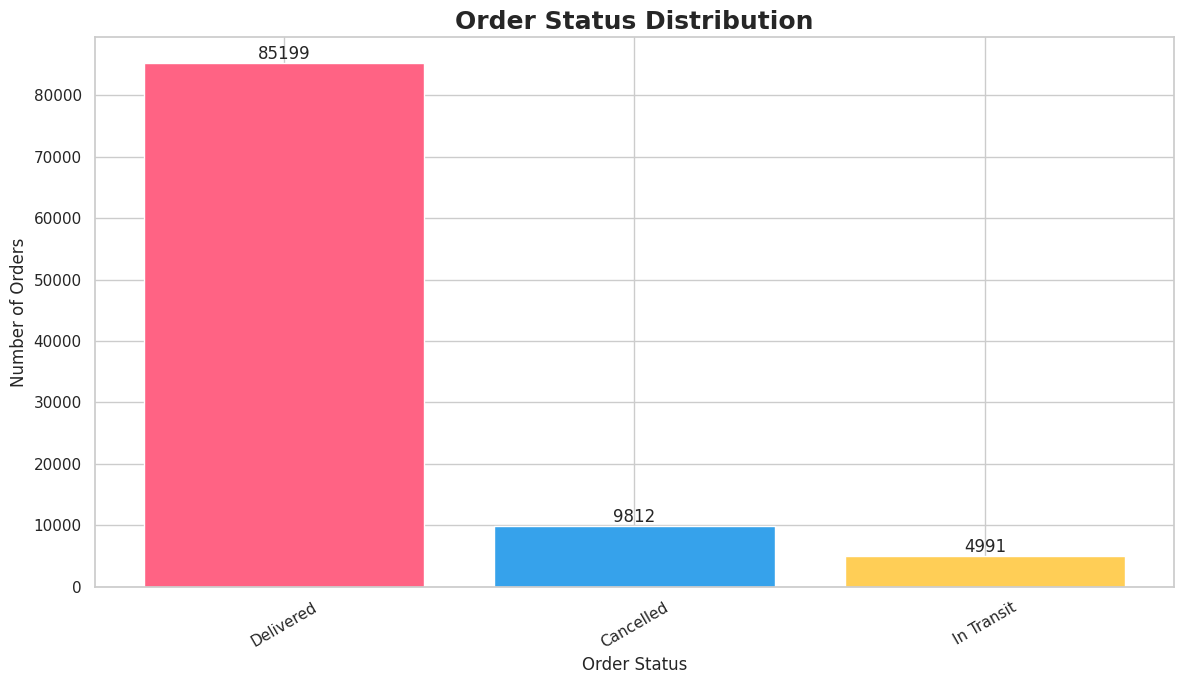

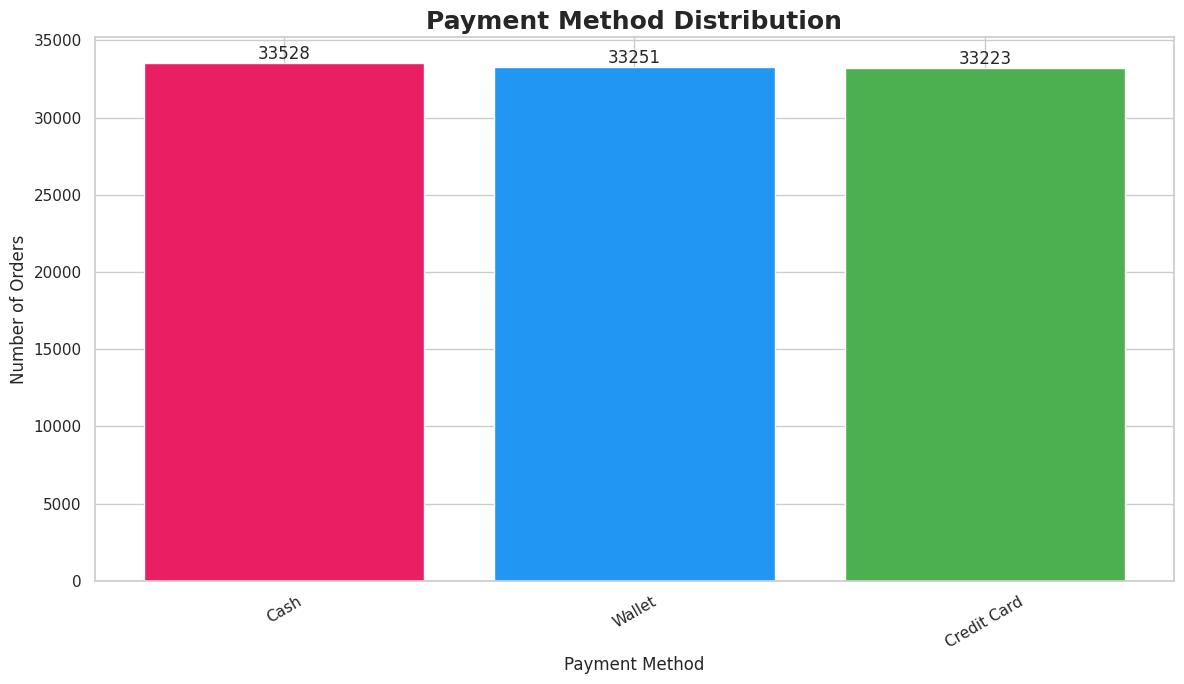

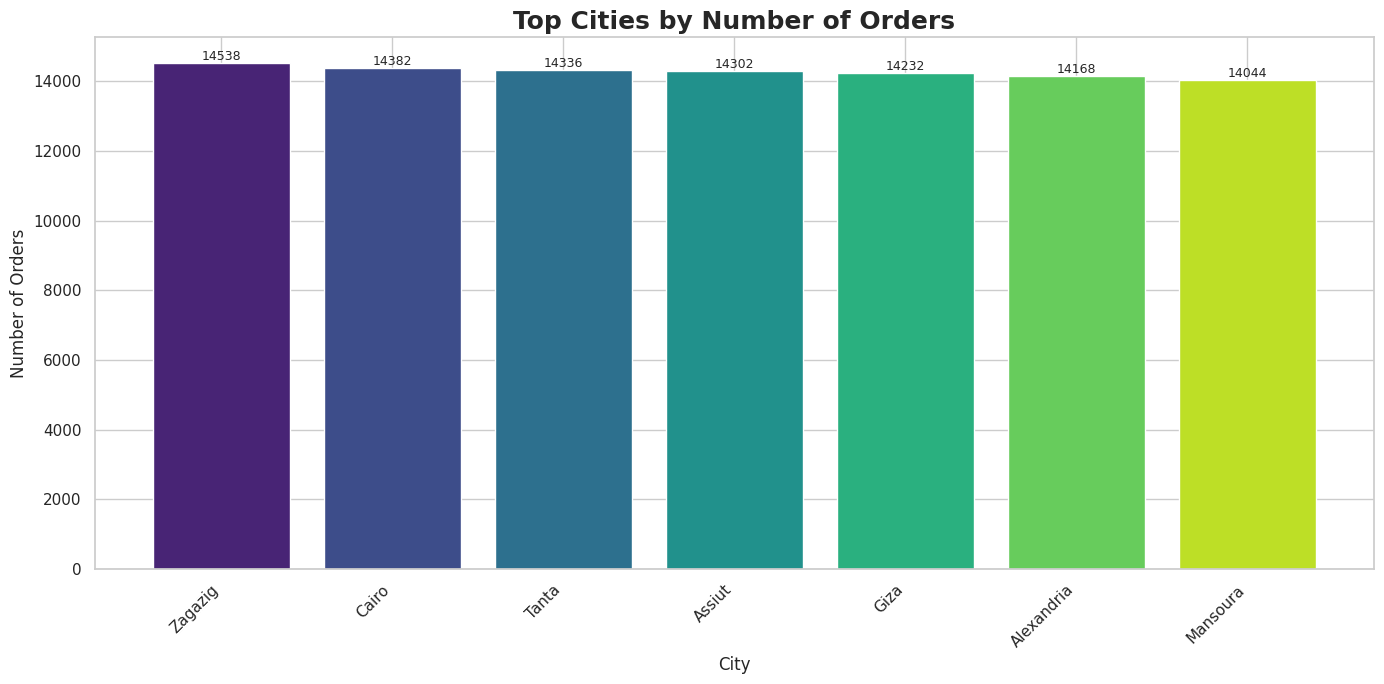

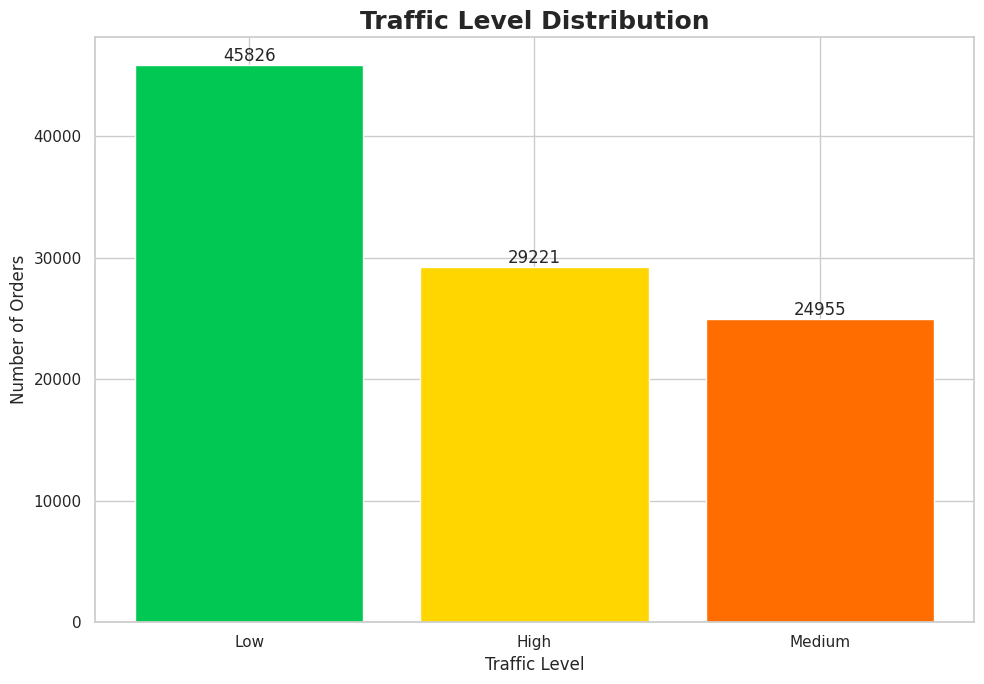

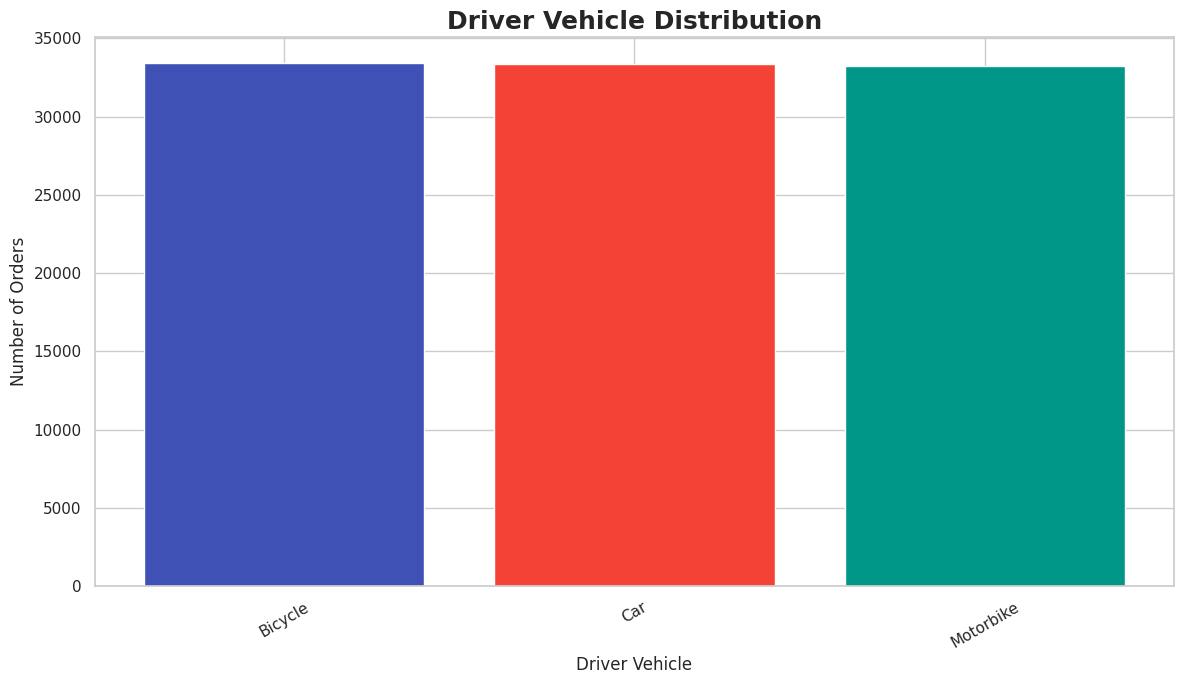

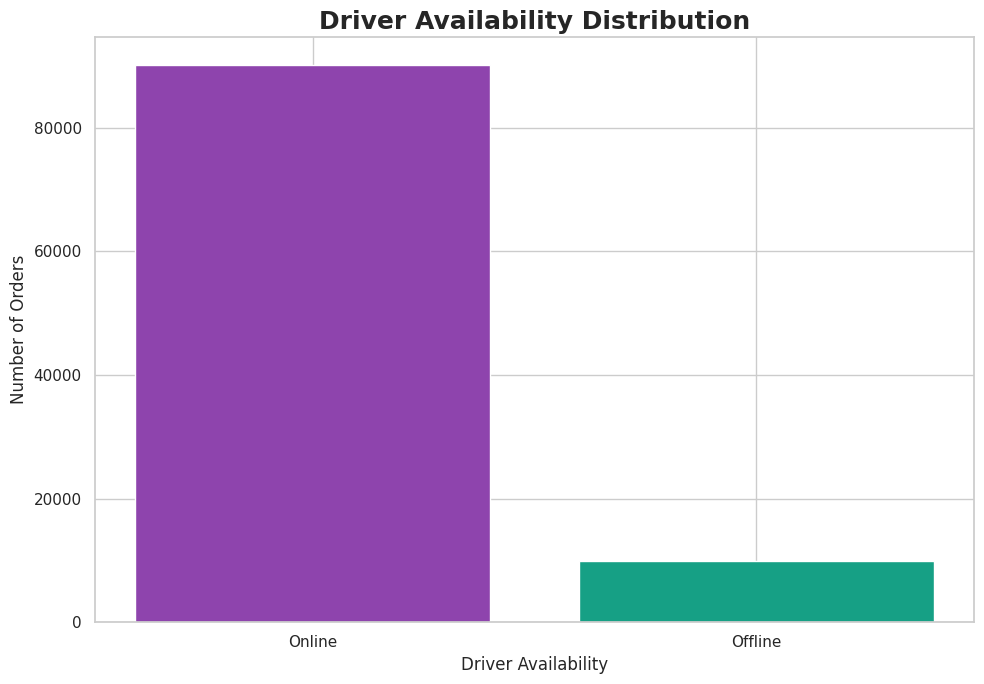

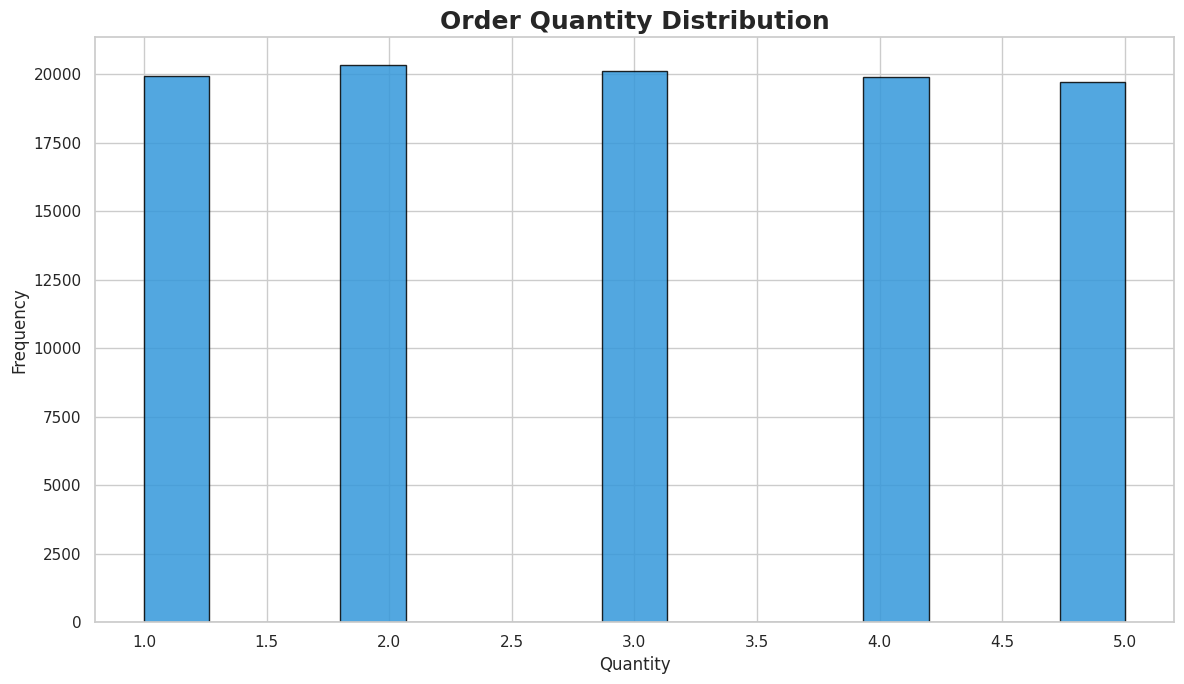

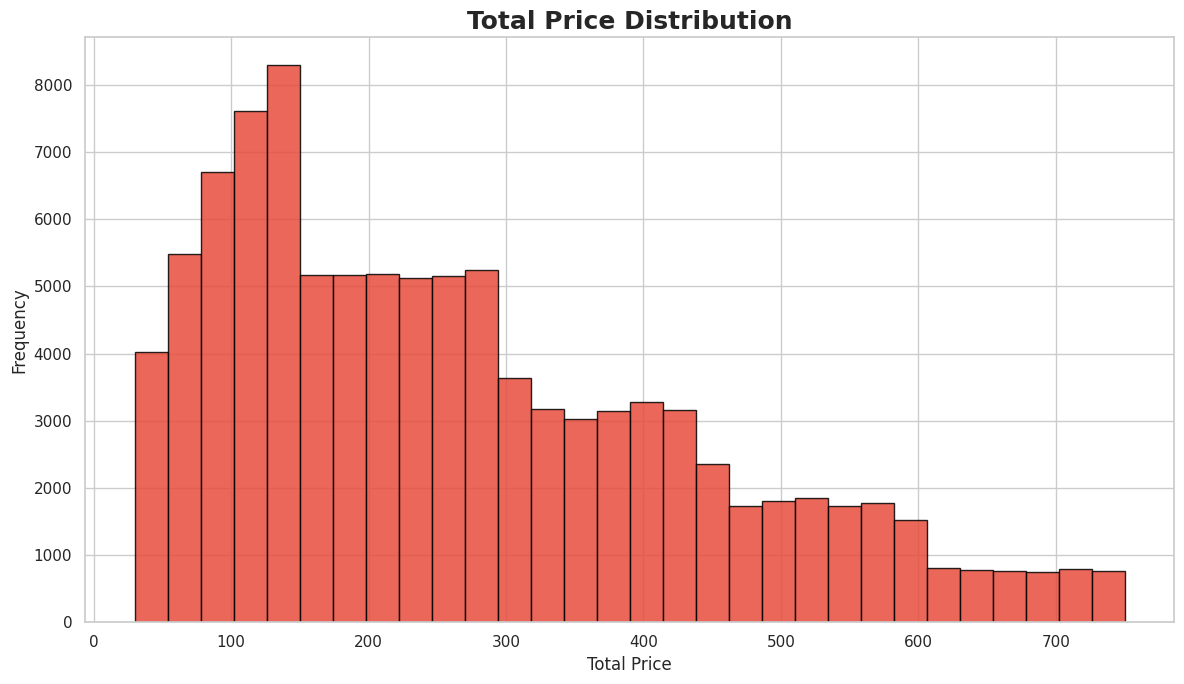

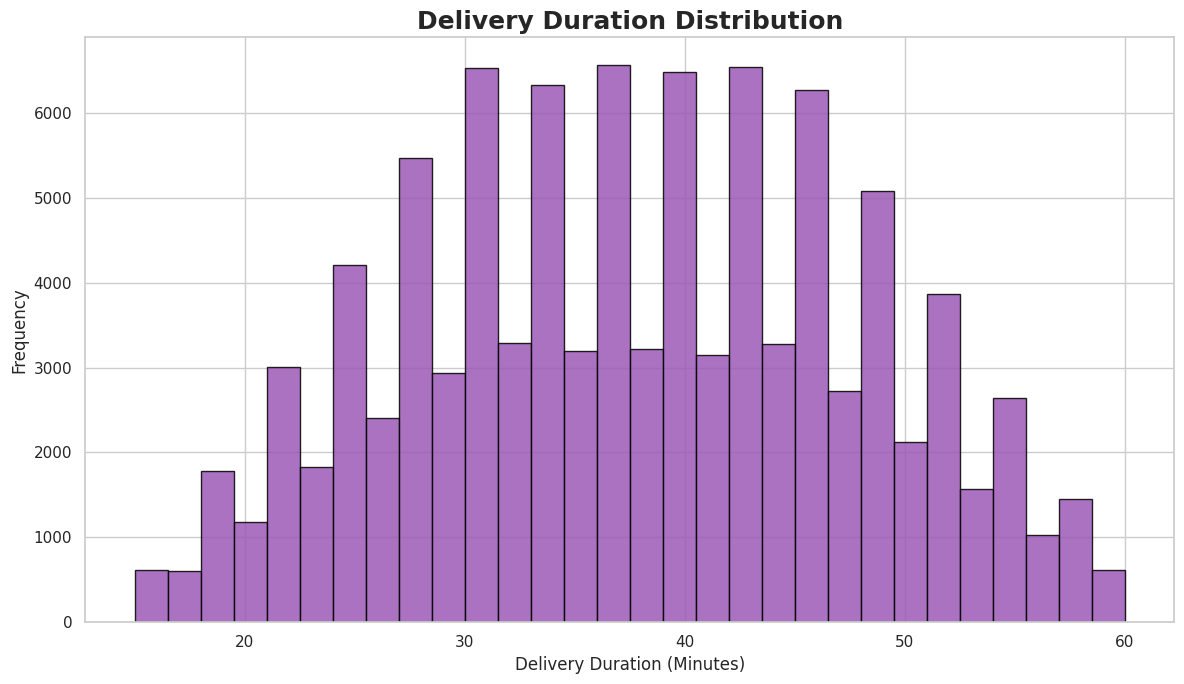

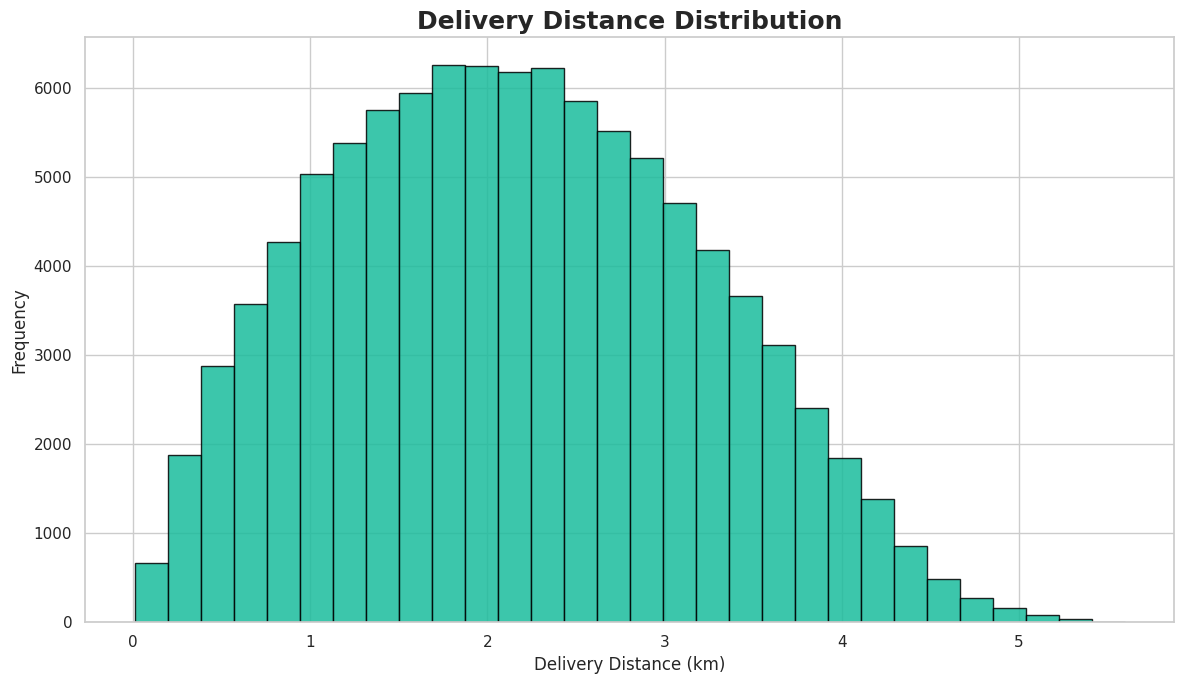

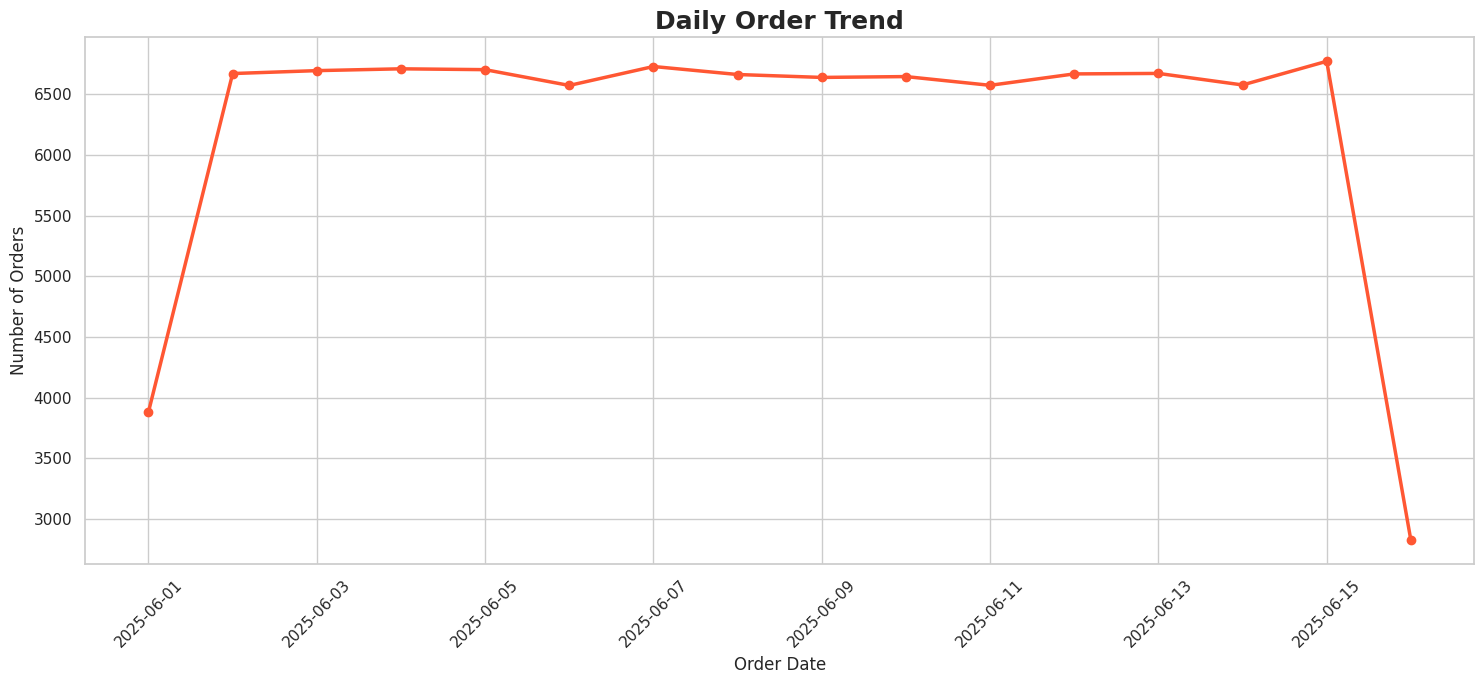

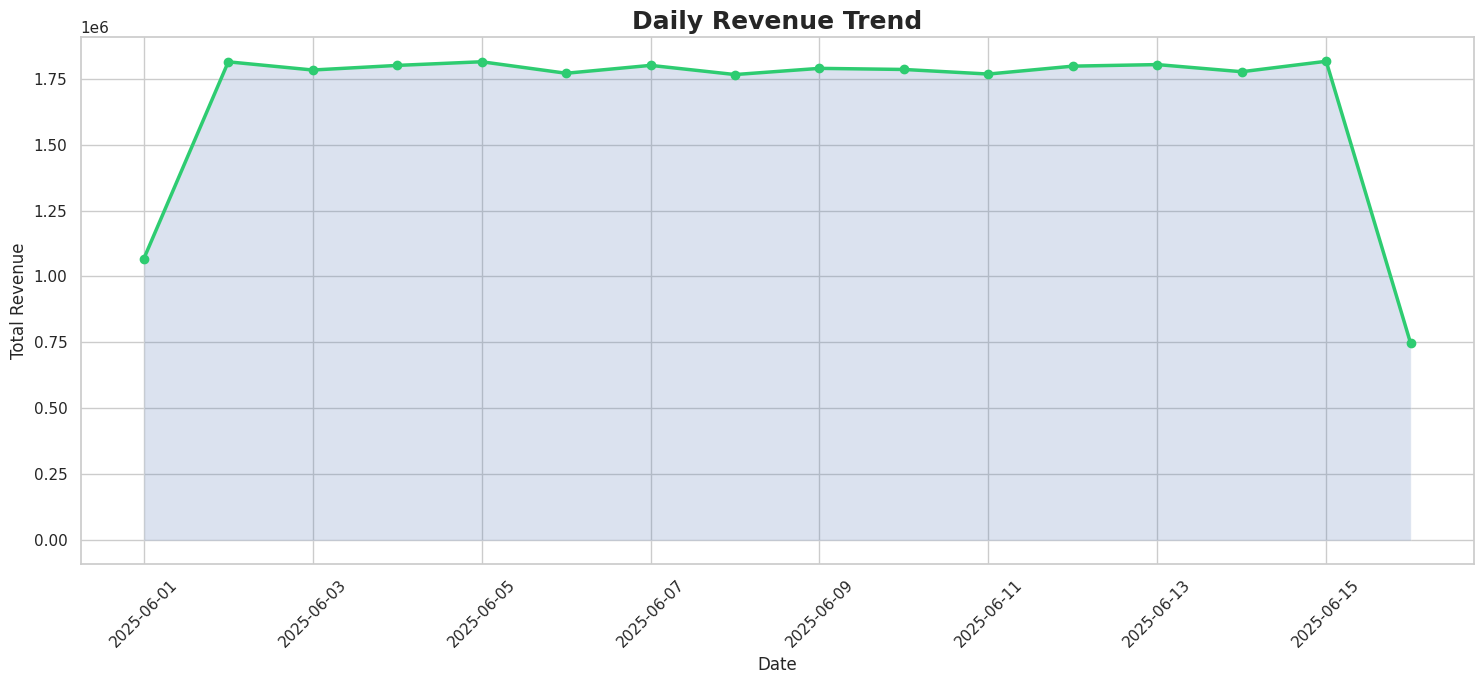

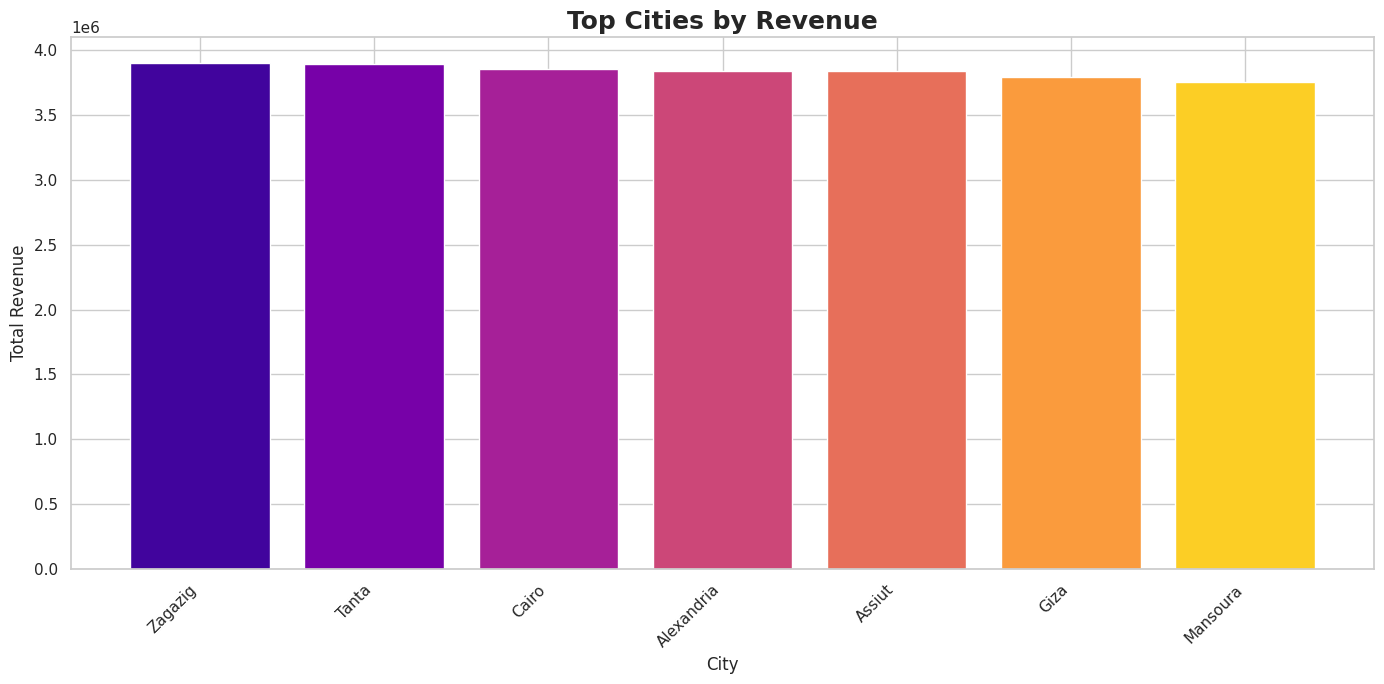

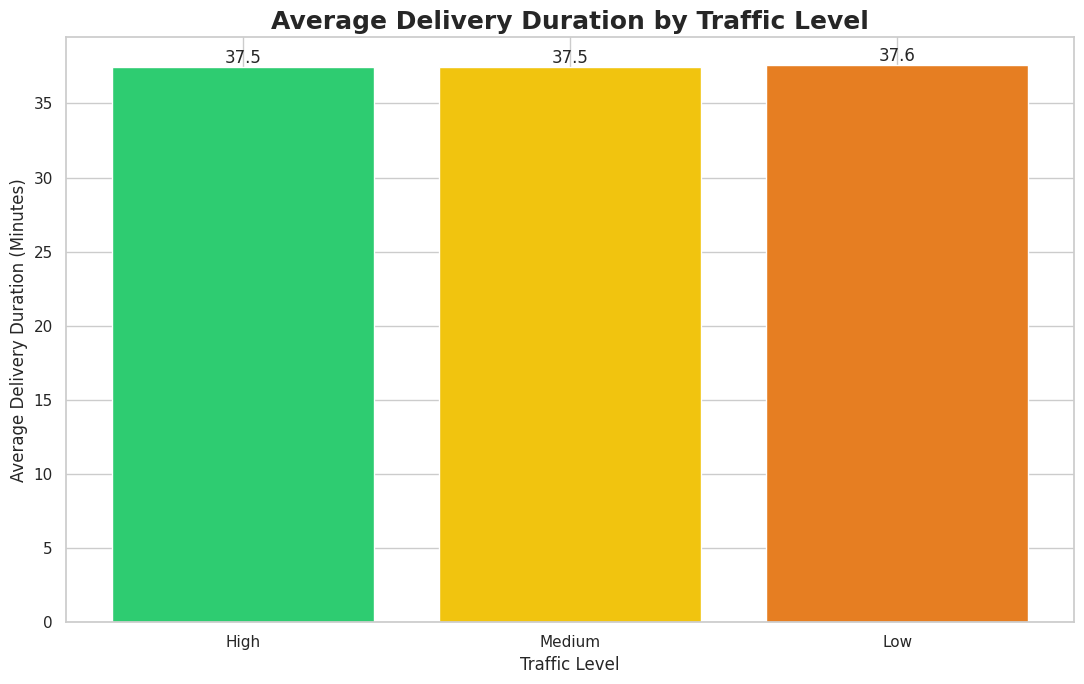

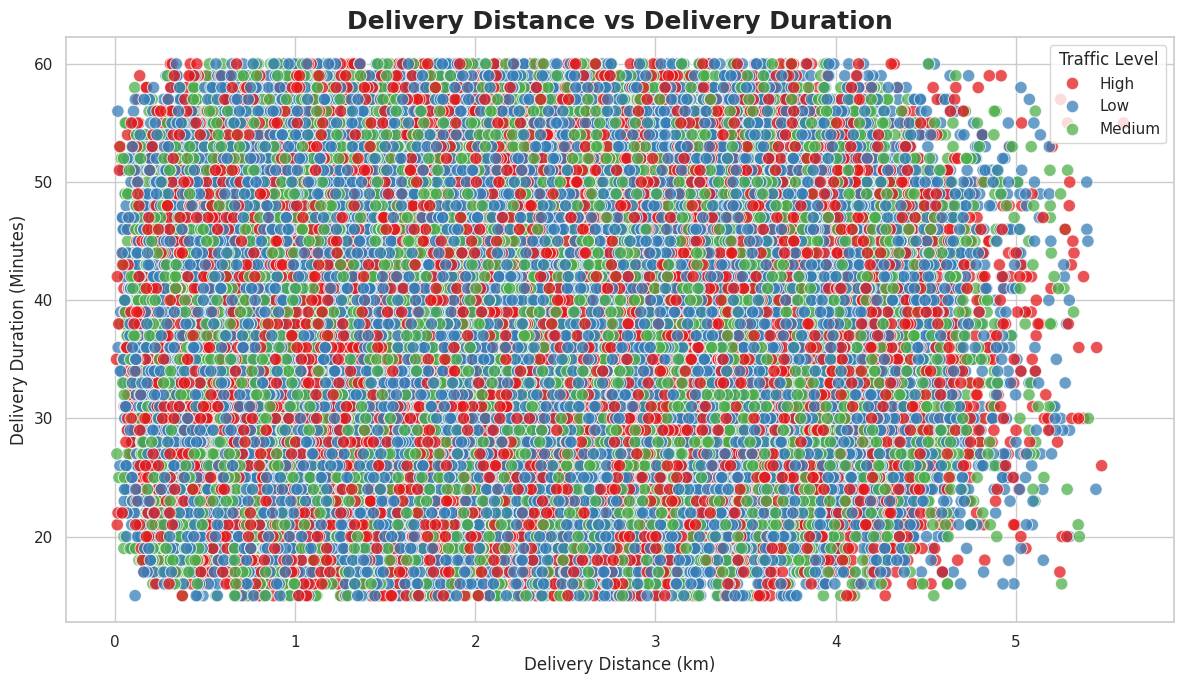

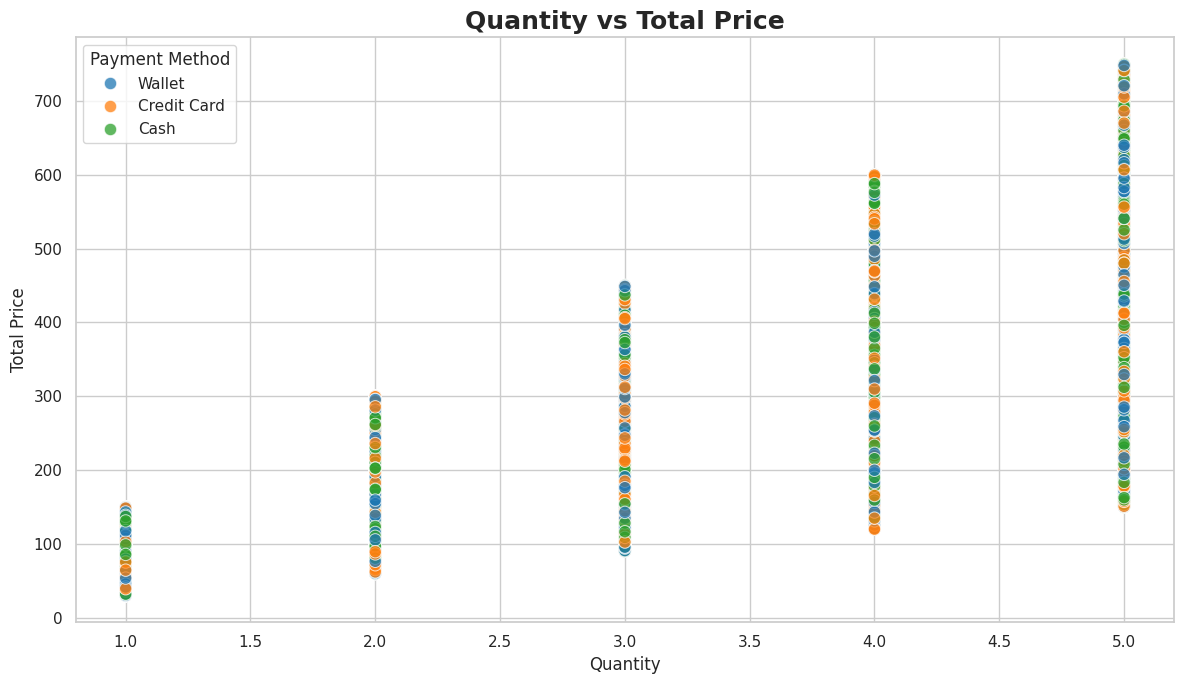

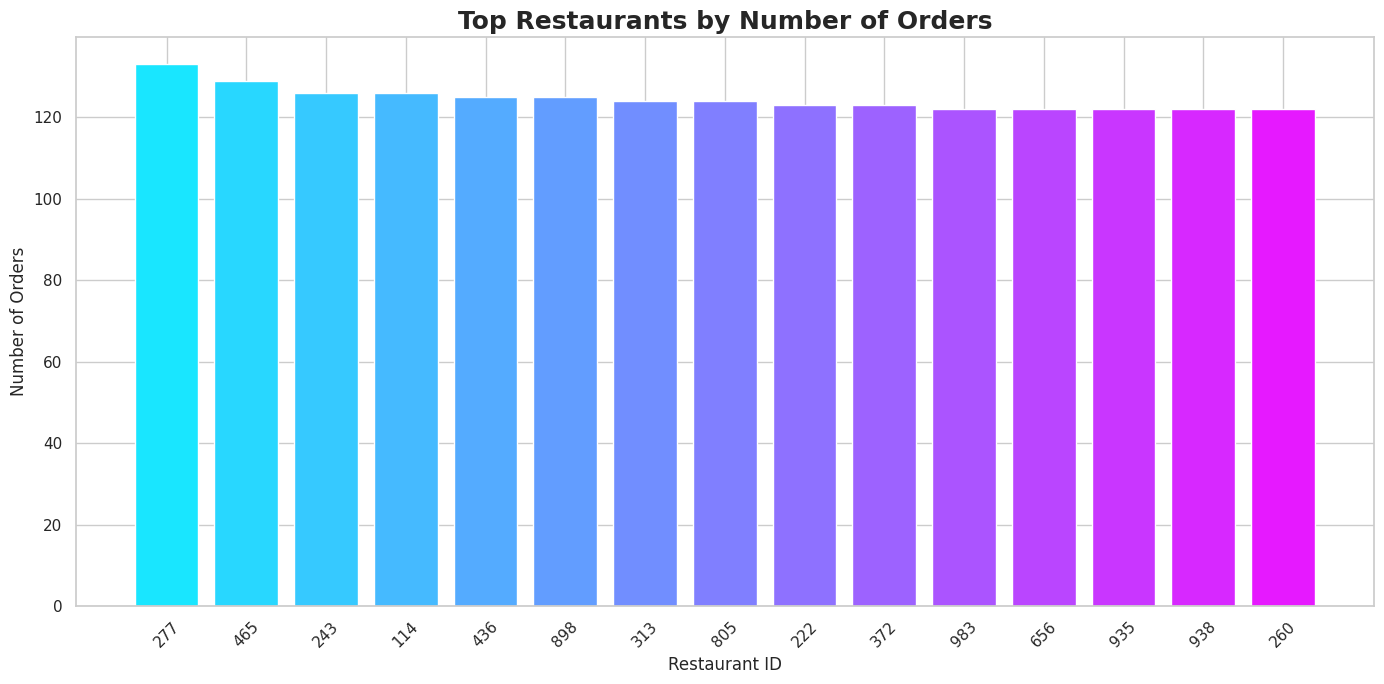

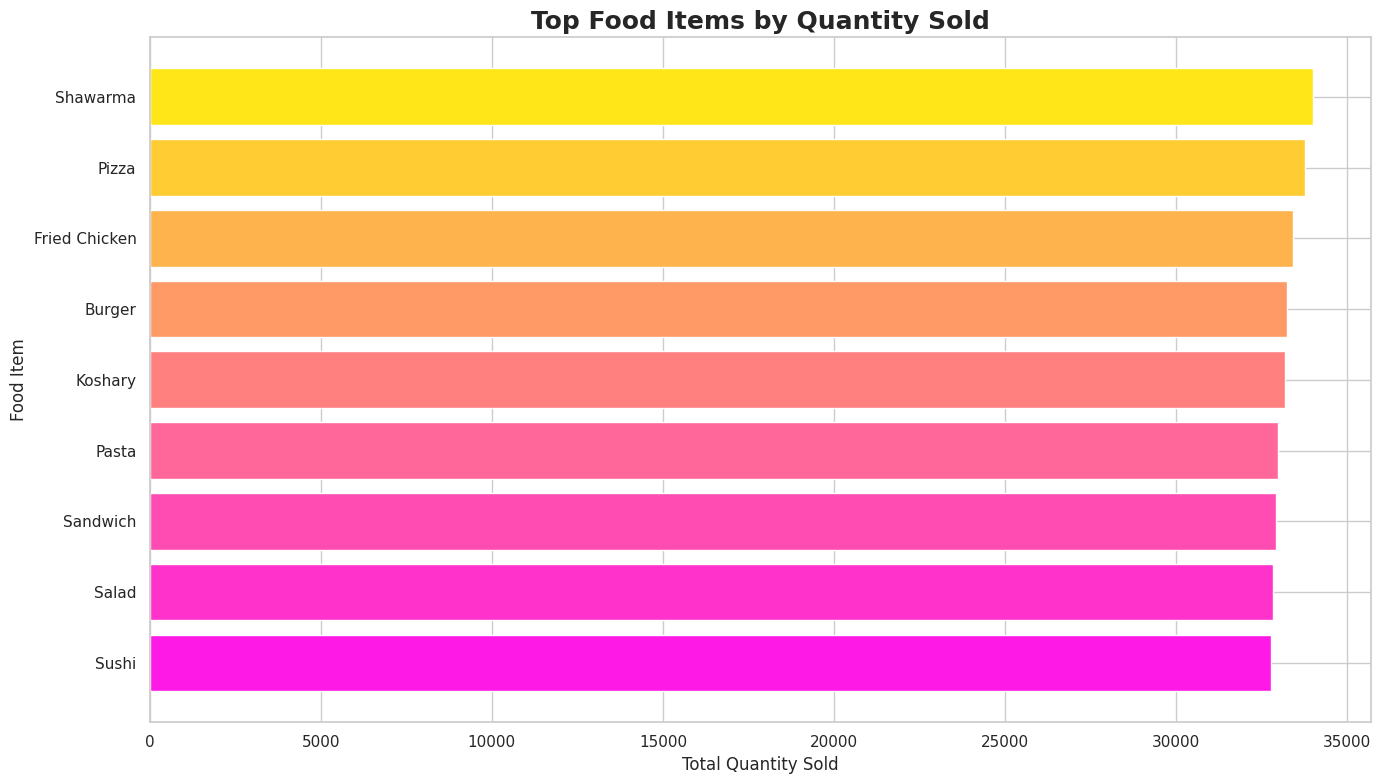

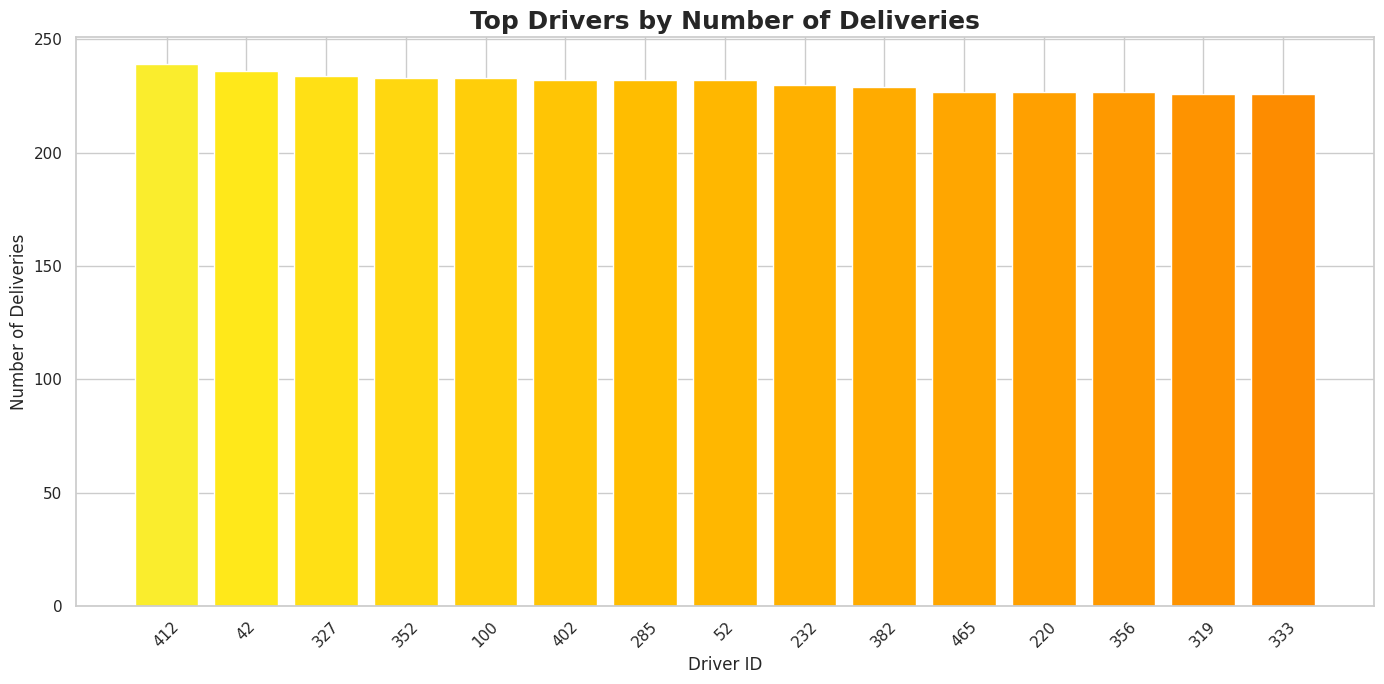

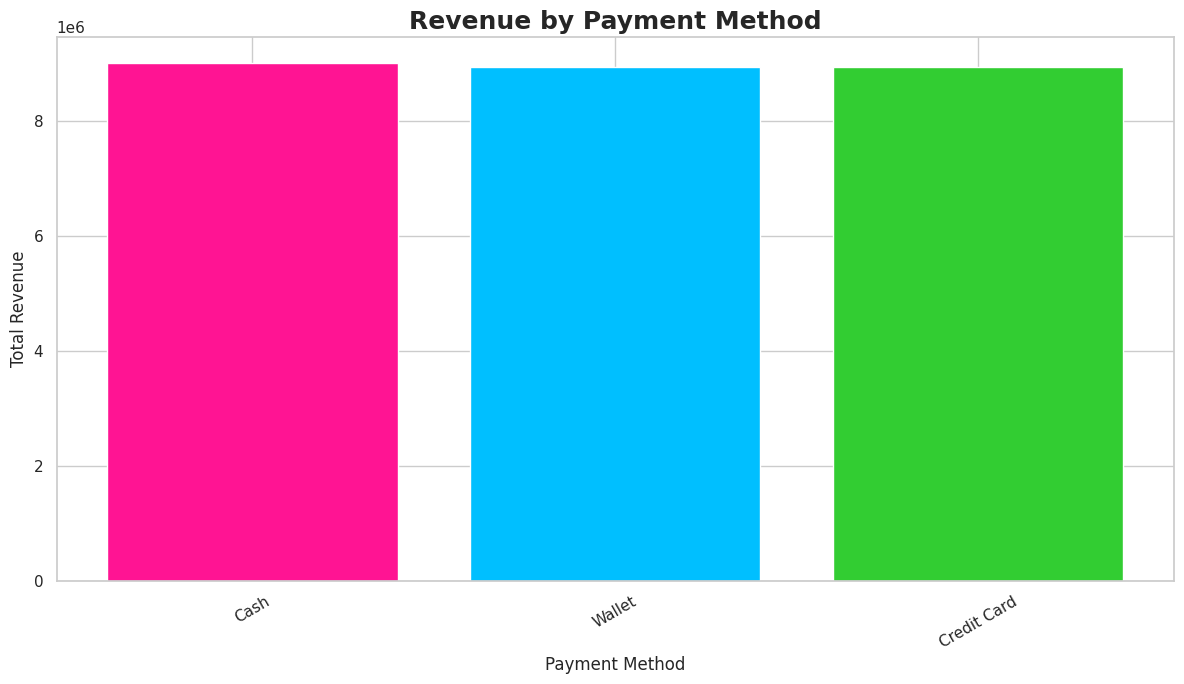

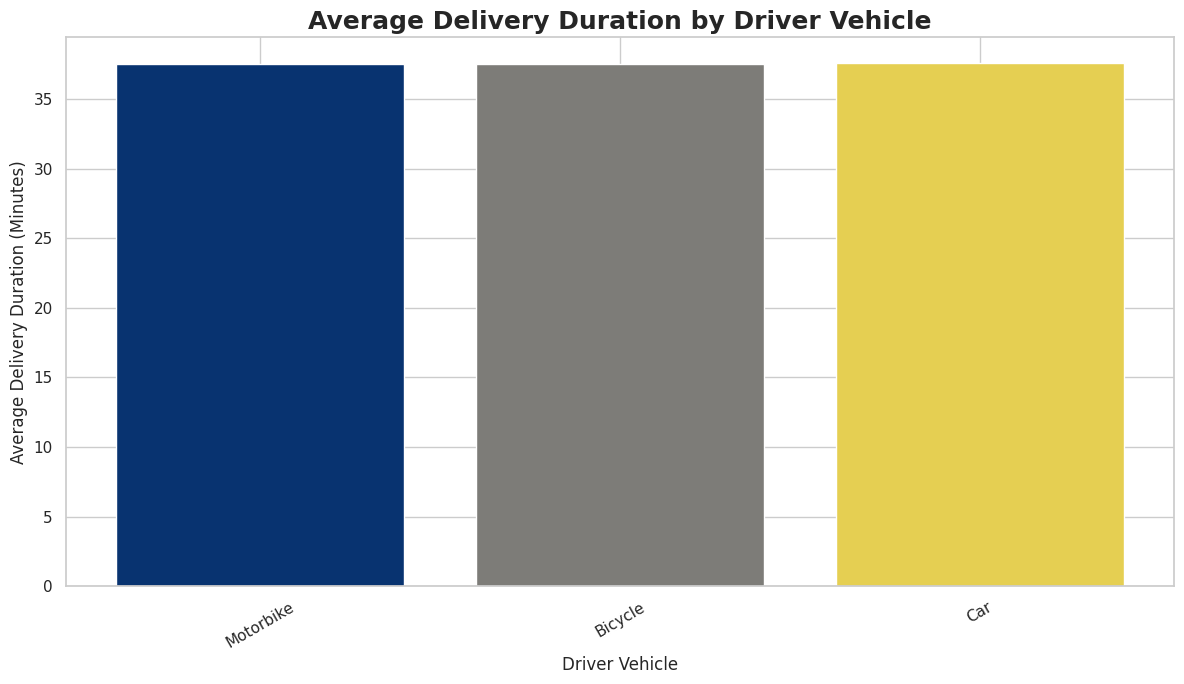

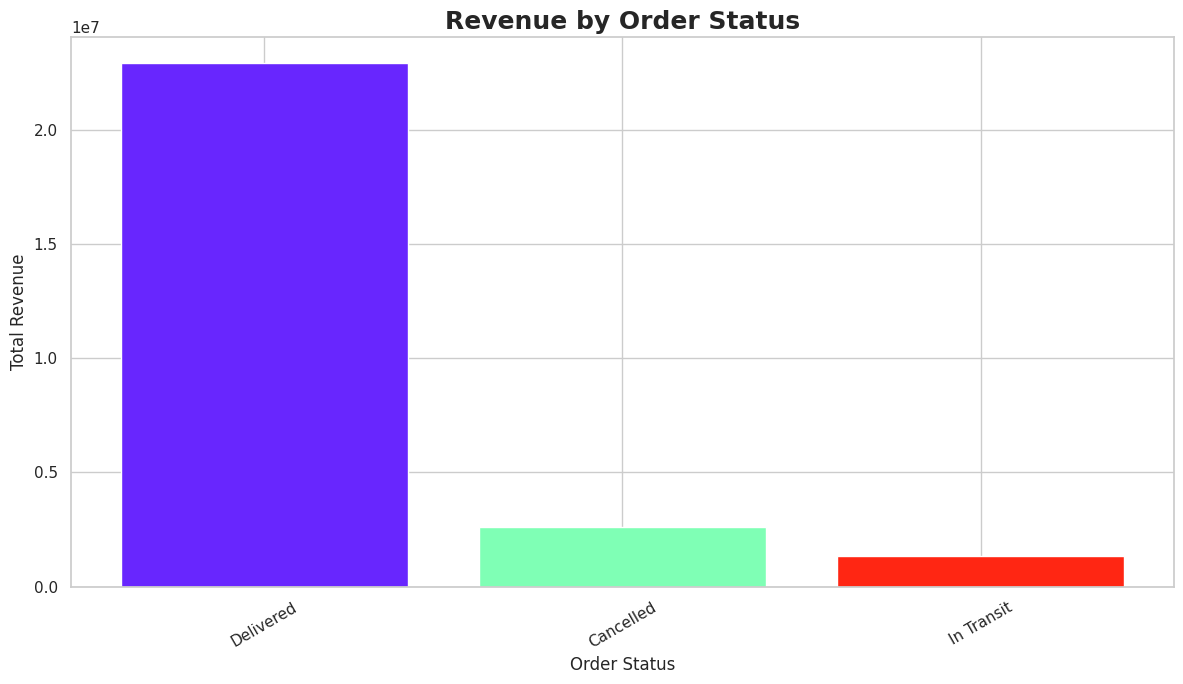

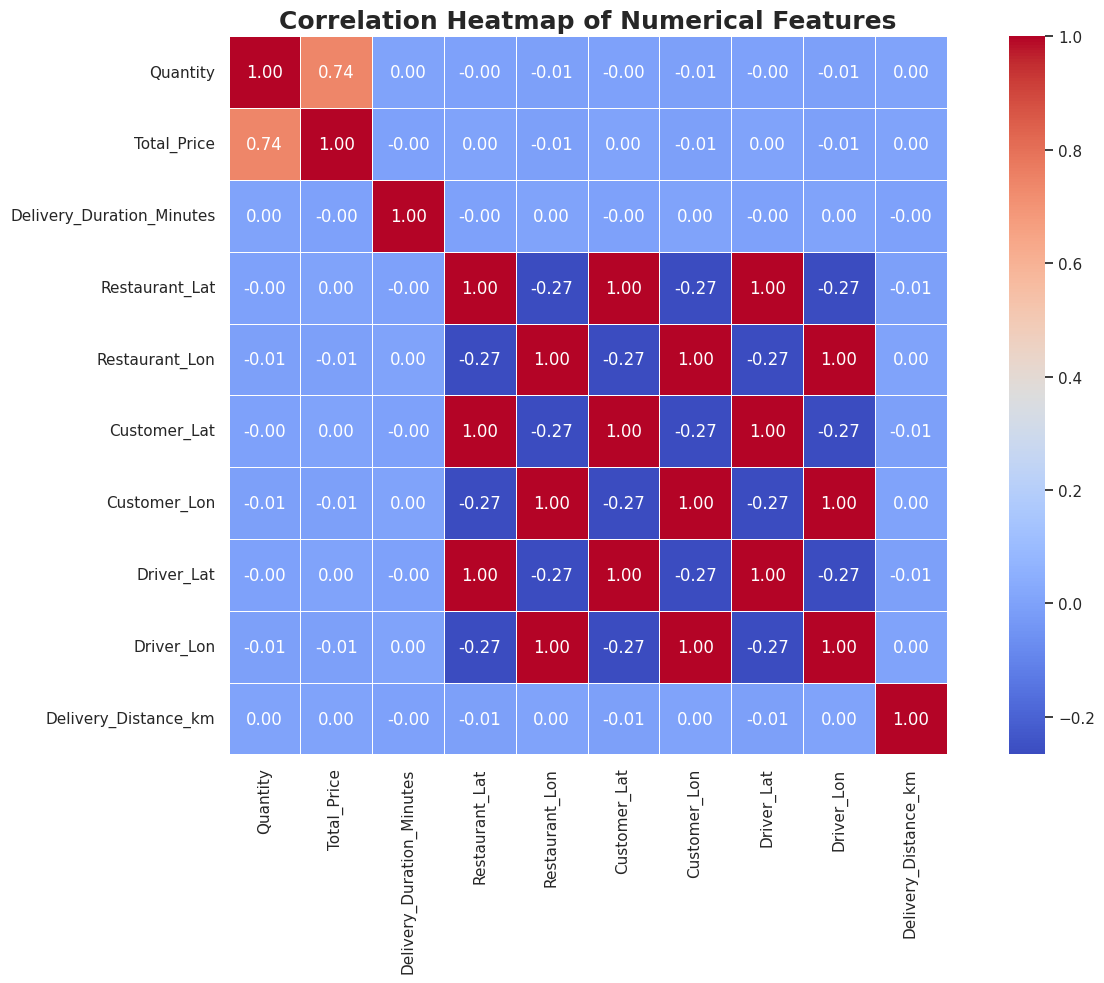

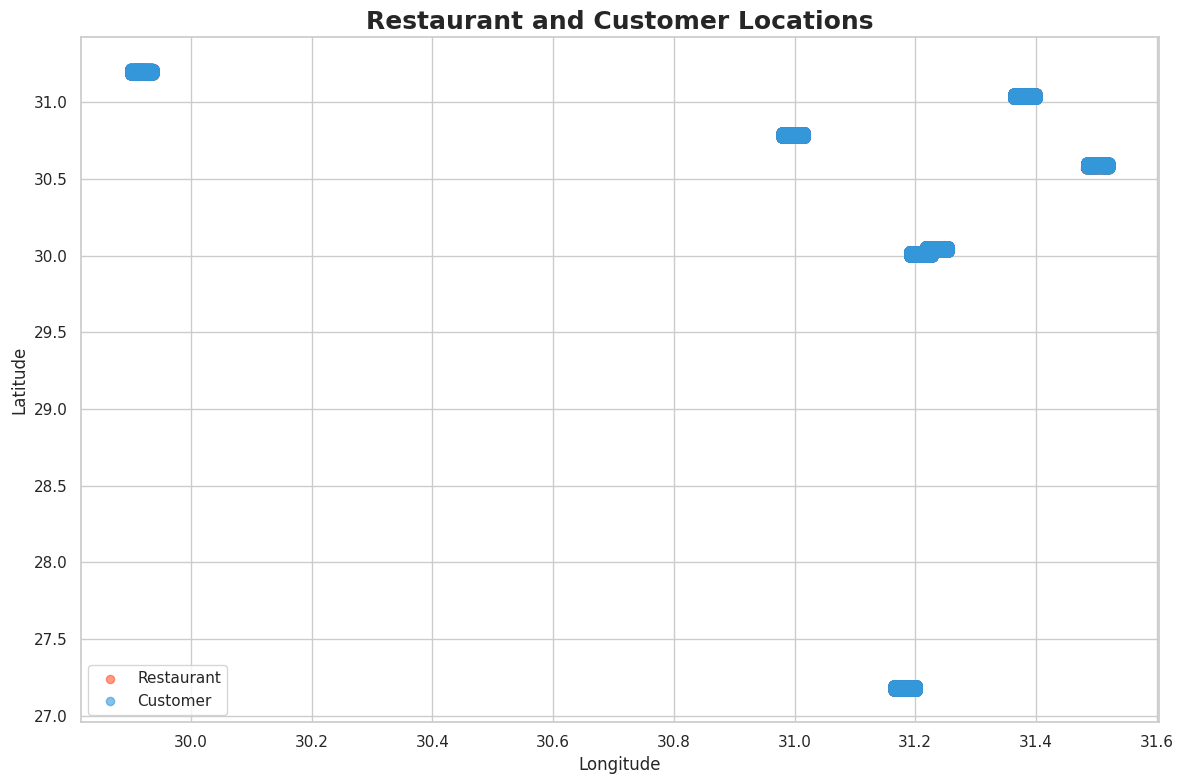

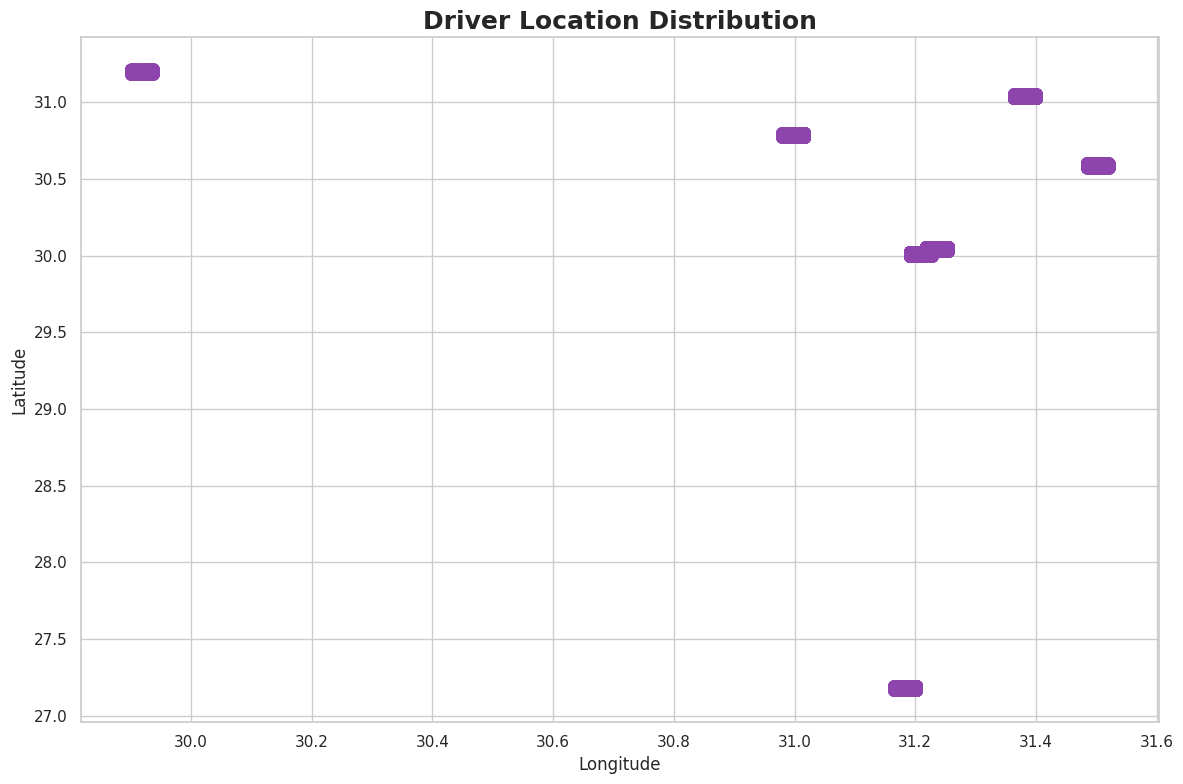

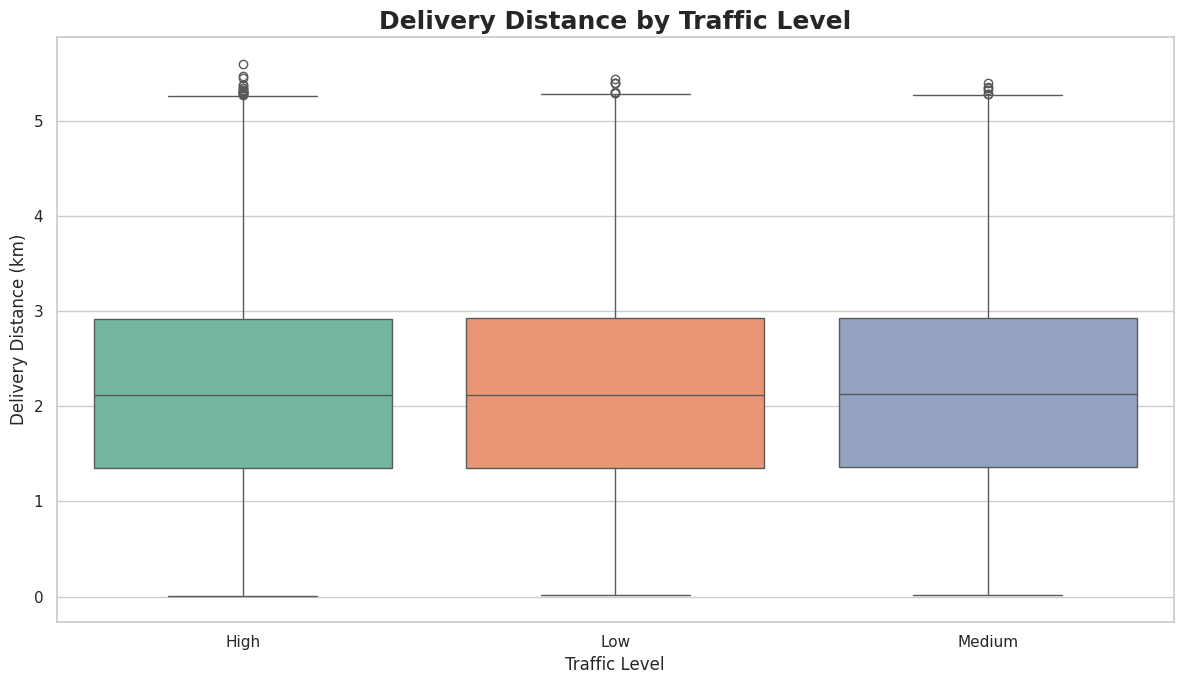

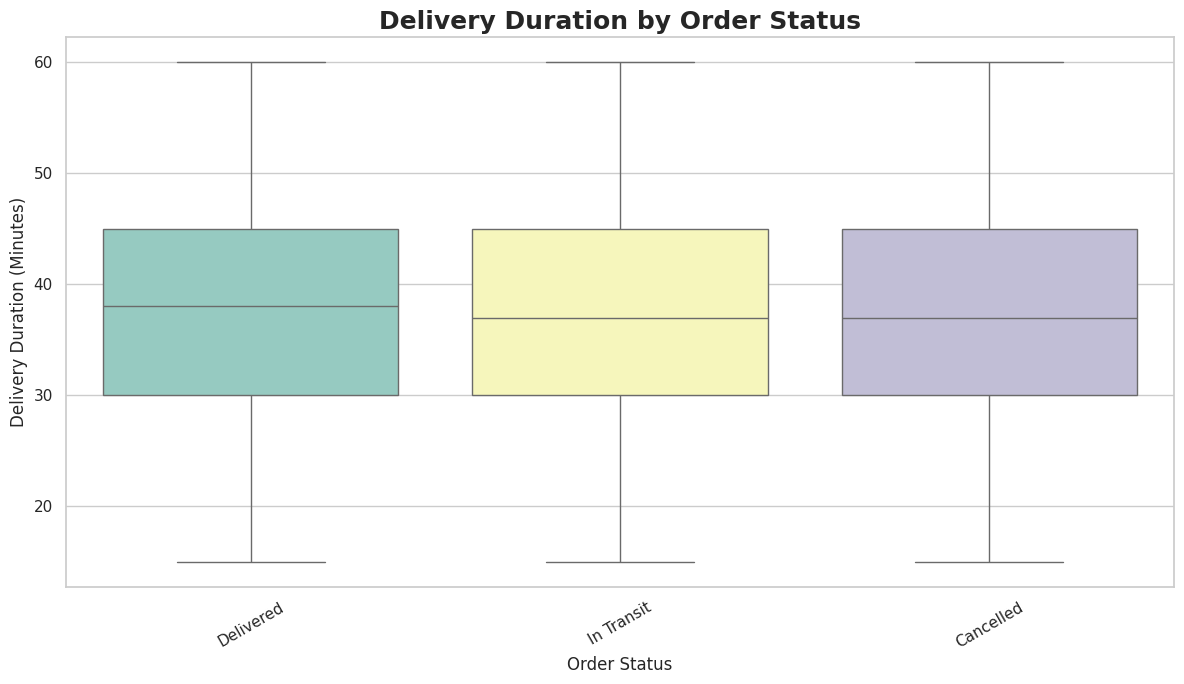

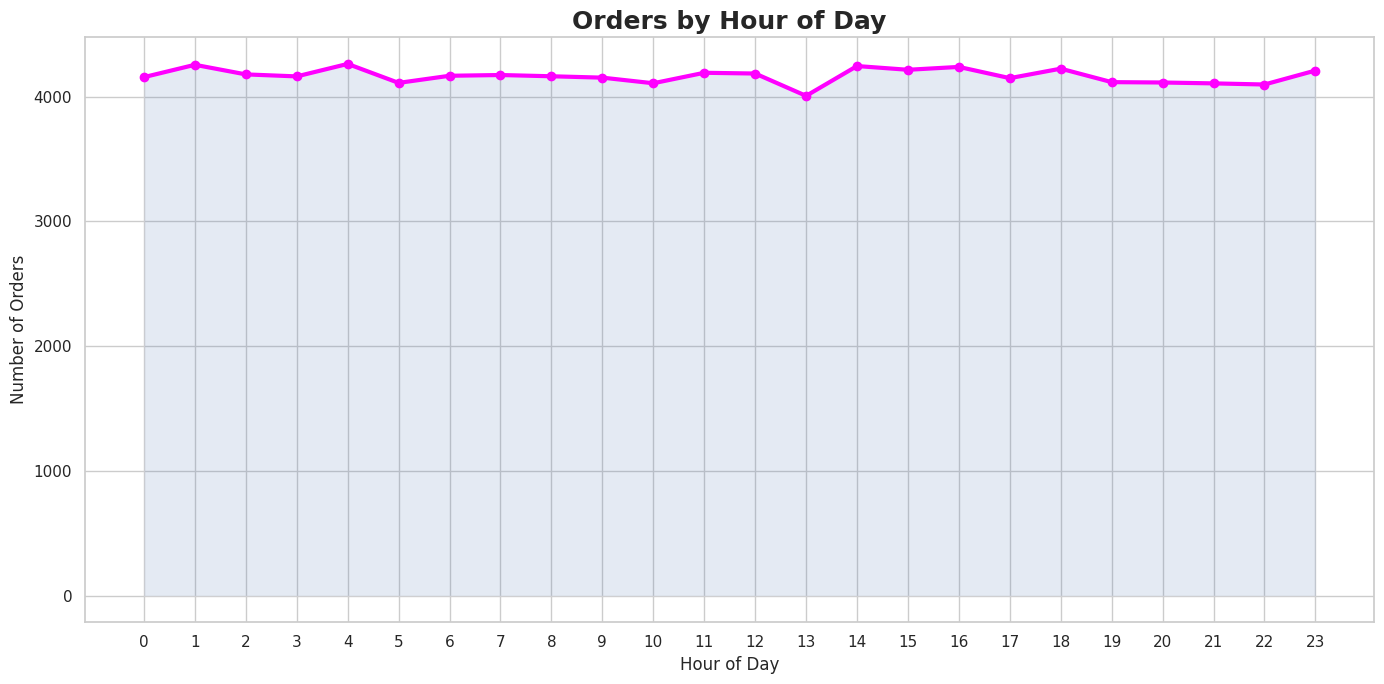

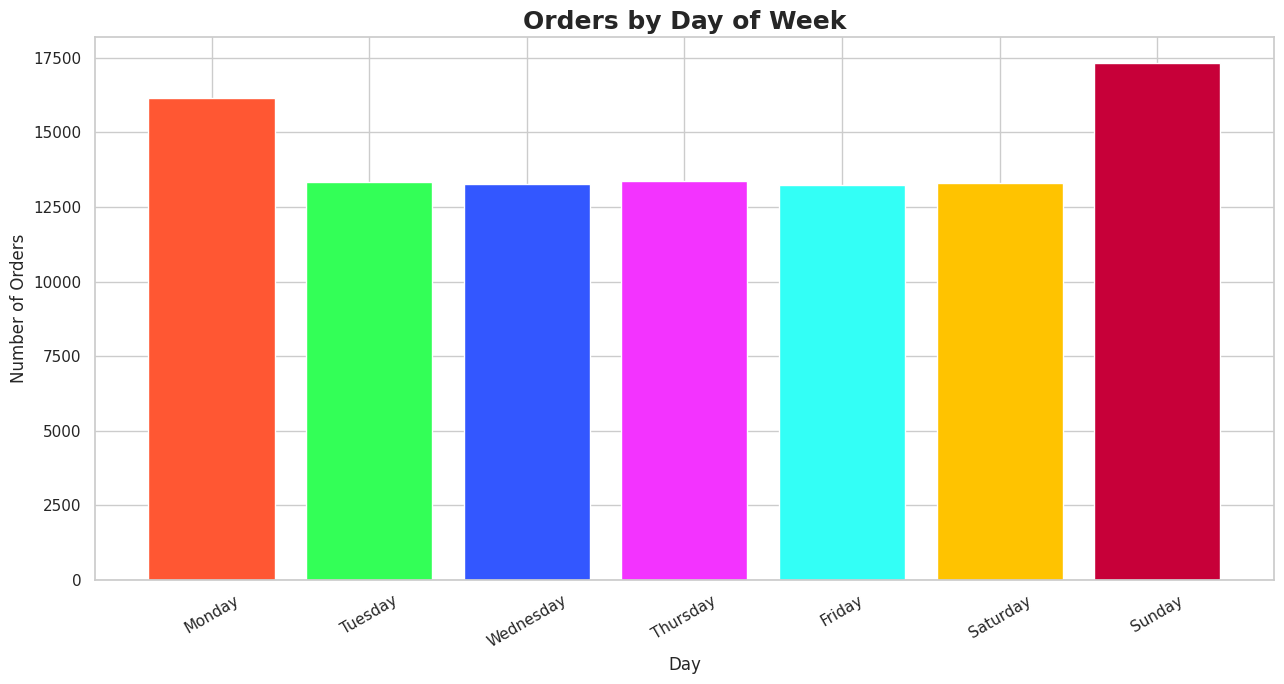

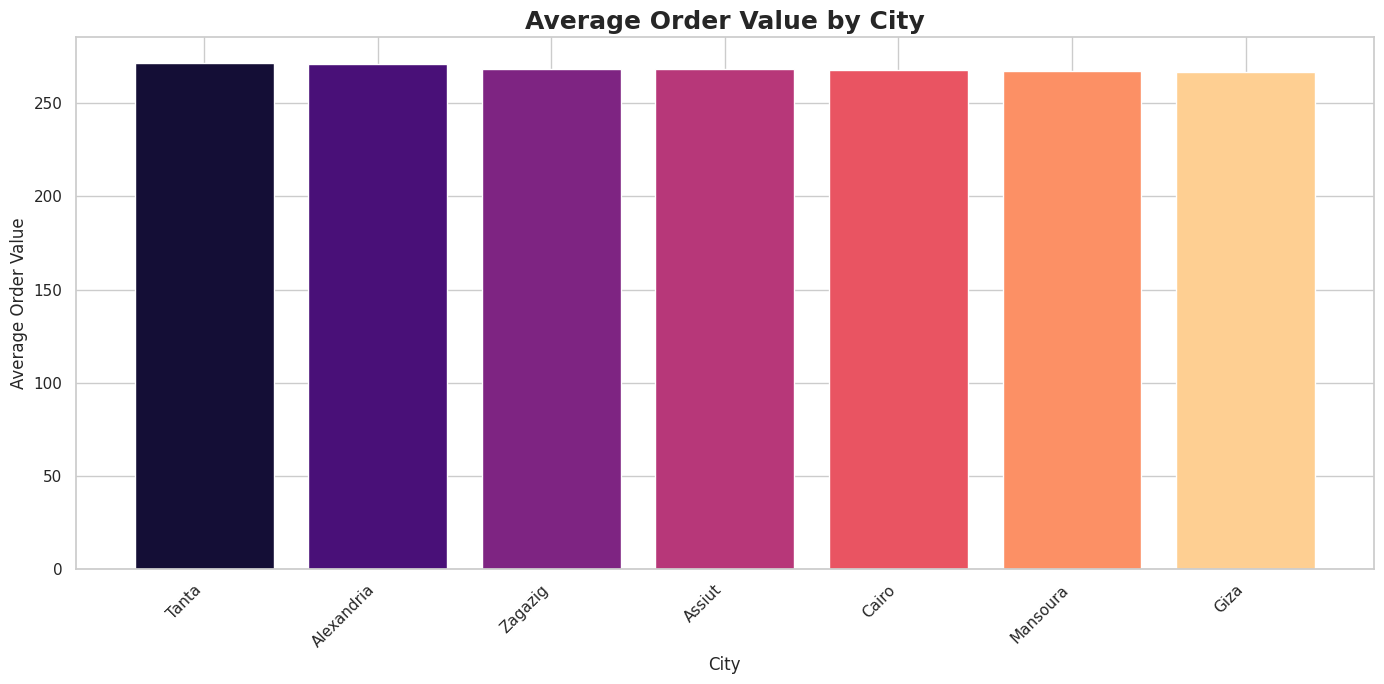



FOOD DELIVERY DATASET SUMMARY
Total Orders: 100002
Total Revenue: 26892805.61
Average Order Value: 268.92
Average Quantity: 2.99
Average Delivery Duration: 37.52 minutes
Average Delivery Distance: 2.17 km
Number of Cities: 7
Number of Restaurants: 1000
Number of Drivers: 500
Number of Food Items: 9

Visualization completed successfully!


In [13]:
# Make a copy so original dataframe is not changed
data = df.copy()

# ------------------------------------------------------------
# 2. DISPLAY BASIC INFORMATION
# ------------------------------------------------------------

print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(data.shape)

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)
print(data.columns.tolist())

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(data.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
print(data.isnull().sum())

# ------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------

# Convert time columns to datetime
data["Order_Time"] = pd.to_datetime(data["Order_Time"], errors="coerce")
data["Delivery_Time"] = pd.to_datetime(data["Delivery_Time"], errors="coerce")

# Convert numerical columns to numeric
numeric_columns = [
    "Quantity",
    "Total_Price",
    "Delivery_Duration_Minutes",
    "Restaurant_Lat",
    "Restaurant_Lon",
    "Customer_Lat",
    "Customer_Lon",
    "Driver_Lat",
    "Driver_Lon",
    "Delivery_Distance_km"
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Remove rows with missing important values only
data = data.dropna(
    subset=[
        "Quantity",
        "Total_Price",
        "Delivery_Duration_Minutes",
        "Delivery_Distance_km"
    ]
)

print("\nCleaned Dataset Shape:", data.shape)

# ------------------------------------------------------------
# 4. SET VISUALIZATION STYLE
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

# ============================================================
# 5. ORDER STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

status_counts = data["Order_Status"].value_counts()

colors = [
    "#FF6384",
    "#36A2EB",
    "#FFCE56",
    "#4BC0C0",
    "#9966FF",
    "#FF9F40"
]

plt.bar(
    status_counts.index,
    status_counts.values,
    color=colors[:len(status_counts)]
)

plt.title("Order Status Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

for i, value in enumerate(status_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


# ============================================================
# 6. PAYMENT METHOD DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

payment_counts = data["Payment_Method"].value_counts()

payment_colors = [
    "#E91E63",
    "#2196F3",
    "#4CAF50",
    "#FF9800",
    "#9C27B0",
    "#00BCD4"
]

plt.bar(
    payment_counts.index,
    payment_counts.values,
    color=payment_colors[:len(payment_counts)]
)

plt.title("Payment Method Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

for i, value in enumerate(payment_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


# ============================================================
# 7. ORDERS BY CITY
# ============================================================

plt.figure(figsize=(14, 7))

city_counts = data["City"].value_counts().head(15)

city_colors = plt.cm.viridis(
    np.linspace(0.1, 0.9, len(city_counts))
)

plt.bar(
    city_counts.index,
    city_counts.values,
    color=city_colors
)

plt.title("Top Cities by Number of Orders", fontsize=18, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")

for i, value in enumerate(city_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 8. TRAFFIC LEVEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 7))

traffic_counts = data["Traffic_Level"].value_counts()

traffic_colors = [
    "#00C853",
    "#FFD600",
    "#FF6D00",
    "#D50000"
]

plt.bar(
    traffic_counts.index,
    traffic_counts.values,
    color=traffic_colors[:len(traffic_counts)]
)

plt.title("Traffic Level Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")

for i, value in enumerate(traffic_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


# ============================================================
# 9. DRIVER VEHICLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

vehicle_counts = data["Driver_Vehicle"].value_counts()

vehicle_colors = [
    "#3F51B5",
    "#F44336",
    "#009688",
    "#FF5722",
    "#795548",
    "#607D8B"
]

plt.bar(
    vehicle_counts.index,
    vehicle_counts.values,
    color=vehicle_colors[:len(vehicle_counts)]
)

plt.title("Driver Vehicle Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Driver Vehicle")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 10. DRIVER AVAILABILITY
# ============================================================

plt.figure(figsize=(10, 7))

availability_counts = data["Driver_Availability"].value_counts()

availability_colors = [
    "#8E44AD",
    "#16A085",
    "#E67E22",
    "#C0392B"
]

plt.bar(
    availability_counts.index.astype(str),
    availability_counts.values,
    color=availability_colors[:len(availability_counts)]
)

plt.title("Driver Availability Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Driver Availability")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# ============================================================
# 11. QUANTITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

plt.hist(
    data["Quantity"],
    bins=15,
    color="#3498DB",
    edgecolor="black",
    alpha=0.85
)

plt.title("Order Quantity Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 12. TOTAL PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

plt.hist(
    data["Total_Price"],
    bins=30,
    color="#E74C3C",
    edgecolor="black",
    alpha=0.85
)

plt.title("Total Price Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 13. DELIVERY DURATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

plt.hist(
    data["Delivery_Duration_Minutes"],
    bins=30,
    color="#9B59B6",
    edgecolor="black",
    alpha=0.85
)

plt.title(
    "Delivery Duration Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Delivery Duration (Minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 14. DELIVERY DISTANCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

plt.hist(
    data["Delivery_Distance_km"],
    bins=30,
    color="#1ABC9C",
    edgecolor="black",
    alpha=0.85
)

plt.title(
    "Delivery Distance Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Delivery Distance (km)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 15. ORDERS OVER TIME
# ============================================================

if data["Order_Time"].notna().any():

    daily_orders = (
        data.dropna(subset=["Order_Time"])
        .set_index("Order_Time")
        .resample("D")
        .size()
    )

    plt.figure(figsize=(15, 7))

    plt.plot(
        daily_orders.index,
        daily_orders.values,
        marker="o",
        linewidth=2.5,
        color="#FF5733"
    )

    plt.title(
        "Daily Order Trend",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Order Date")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 16. REVENUE OVER TIME
# ============================================================

if data["Order_Time"].notna().any():

    daily_revenue = (
        data.dropna(subset=["Order_Time"])
        .set_index("Order_Time")["Total_Price"]
        .resample("D")
        .sum()
    )

    plt.figure(figsize=(15, 7))

    plt.plot(
        daily_revenue.index,
        daily_revenue.values,
        marker="o",
        linewidth=2.5,
        color="#2ECC71"
    )

    plt.fill_between(
        daily_revenue.index,
        daily_revenue.values,
        alpha=0.2
    )

    plt.title(
        "Daily Revenue Trend",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Date")
    plt.ylabel("Total Revenue")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. CITY-WISE REVENUE
# ============================================================

city_revenue = (
    data.groupby("City")["Total_Price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14, 7))

city_revenue_colors = plt.cm.plasma(
    np.linspace(0.1, 0.9, len(city_revenue))
)

plt.bar(
    city_revenue.index,
    city_revenue.values,
    color=city_revenue_colors
)

plt.title(
    "Top Cities by Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# ============================================================
# 18. TRAFFIC LEVEL VS DELIVERY DURATION
# ============================================================

traffic_duration = (
    data.groupby("Traffic_Level")["Delivery_Duration_Minutes"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(11, 7))

plt.bar(
    traffic_duration.index,
    traffic_duration.values,
    color=["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"][:len(traffic_duration)]
)

plt.title(
    "Average Delivery Duration by Traffic Level",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Duration (Minutes)")

for i, value in enumerate(traffic_duration.values):
    plt.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 19. DELIVERY DISTANCE VS DELIVERY DURATION
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=data,
    x="Delivery_Distance_km",
    y="Delivery_Duration_Minutes",
    hue="Traffic_Level",
    palette="Set1",
    s=80,
    alpha=0.75
)

plt.title(
    "Delivery Distance vs Delivery Duration",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Duration (Minutes)")
plt.legend(title="Traffic Level")

plt.tight_layout()
plt.show()


# ============================================================
# 20. QUANTITY VS TOTAL PRICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=data,
    x="Quantity",
    y="Total_Price",
    hue="Payment_Method",
    palette="tab10",
    s=80,
    alpha=0.75
)

plt.title(
    "Quantity vs Total Price",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.legend(title="Payment Method")

plt.tight_layout()
plt.show()


# ============================================================
# 21. TOP RESTAURANTS BY NUMBER OF ORDERS
# ============================================================

restaurant_orders = (
    data["Restaurant_ID"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14, 7))

restaurant_colors = plt.cm.cool(
    np.linspace(0.1, 0.9, len(restaurant_orders))
)

plt.bar(
    restaurant_orders.index.astype(str),
    restaurant_orders.values,
    color=restaurant_colors
)

plt.title(
    "Top Restaurants by Number of Orders",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Restaurant ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 22. TOP FOOD ITEMS
# ============================================================

item_orders = (
    data.groupby("Item_Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14, 8))

item_colors = plt.cm.spring(
    np.linspace(0.1, 0.9, len(item_orders))
)

plt.barh(
    item_orders.index[::-1],
    item_orders.values[::-1],
    color=item_colors
)

plt.title(
    "Top Food Items by Quantity Sold",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Total Quantity Sold")
plt.ylabel("Food Item")

plt.tight_layout()
plt.show()


# ============================================================
# 23. DRIVER-WISE ORDER COUNT
# ============================================================

driver_orders = (
    data["Driver_ID"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14, 7))

driver_colors = plt.cm.Wistia(
    np.linspace(0.2, 0.9, len(driver_orders))
)

plt.bar(
    driver_orders.index.astype(str),
    driver_orders.values,
    color=driver_colors
)

plt.title(
    "Top Drivers by Number of Deliveries",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Driver ID")
plt.ylabel("Number of Deliveries")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 24. PAYMENT METHOD VS REVENUE
# ============================================================

payment_revenue = (
    data.groupby("Payment_Method")["Total_Price"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

payment_revenue_colors = [
    "#FF1493",
    "#00BFFF",
    "#32CD32",
    "#FF8C00",
    "#8A2BE2",
    "#00CED1"
]

plt.bar(
    payment_revenue.index,
    payment_revenue.values,
    color=payment_revenue_colors[:len(payment_revenue)]
)

plt.title(
    "Revenue by Payment Method",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 25. VEHICLE VS DELIVERY DURATION
# ============================================================

vehicle_duration = (
    data.groupby("Driver_Vehicle")["Delivery_Duration_Minutes"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 7))

vehicle_duration_colors = plt.cm.cividis(
    np.linspace(0.1, 0.9, len(vehicle_duration))
)

plt.bar(
    vehicle_duration.index,
    vehicle_duration.values,
    color=vehicle_duration_colors
)

plt.title(
    "Average Delivery Duration by Driver Vehicle",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Driver Vehicle")
plt.ylabel("Average Delivery Duration (Minutes)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 26. ORDER STATUS VS REVENUE
# ============================================================

status_revenue = (
    data.groupby("Order_Status")["Total_Price"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

status_revenue_colors = plt.cm.rainbow(
    np.linspace(0.05, 0.95, len(status_revenue))
)

plt.bar(
    status_revenue.index,
    status_revenue.values,
    color=status_revenue_colors
)

plt.title(
    "Revenue by Order Status",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Order Status")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 27. CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    "Quantity",
    "Total_Price",
    "Delivery_Duration_Minutes",
    "Restaurant_Lat",
    "Restaurant_Lon",
    "Customer_Lat",
    "Customer_Lon",
    "Driver_Lat",
    "Driver_Lon",
    "Delivery_Distance_km"
]

correlation_columns = [
    col for col in correlation_columns
    if col in data.columns
]

correlation_matrix = data[correlation_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 28. CUSTOMER VS RESTAURANT LOCATION
# ============================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    data["Restaurant_Lon"],
    data["Restaurant_Lat"],
    s=35,
    alpha=0.6,
    color="#FF5733",
    label="Restaurant"
)

plt.scatter(
    data["Customer_Lon"],
    data["Customer_Lat"],
    s=35,
    alpha=0.6,
    color="#3498DB",
    label="Customer"
)

plt.title(
    "Restaurant and Customer Locations",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 29. DRIVER LOCATION
# ============================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    data["Driver_Lon"],
    data["Driver_Lat"],
    s=40,
    alpha=0.65,
    color="#8E44AD"
)

plt.title(
    "Driver Location Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()


# ============================================================
# 30. DELIVERY DISTANCE BY TRAFFIC LEVEL
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=data,
    x="Traffic_Level",
    y="Delivery_Distance_km",
    hue="Traffic_Level",
    palette="Set2",
    legend=False
)

plt.title(
    "Delivery Distance by Traffic Level",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Traffic Level")
plt.ylabel("Delivery Distance (km)")

plt.tight_layout()
plt.show()


# ============================================================
# 31. DELIVERY DURATION BY ORDER STATUS
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=data,
    x="Order_Status",
    y="Delivery_Duration_Minutes",
    hue="Order_Status",
    palette="Set3",
    legend=False
)

plt.title(
    "Delivery Duration by Order Status",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Order Status")
plt.ylabel("Delivery Duration (Minutes)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 32. HOURLY ORDER ANALYSIS
# ============================================================

if data["Order_Time"].notna().any():

    data["Order_Hour"] = data["Order_Time"].dt.hour

    hourly_orders = (
        data.groupby("Order_Hour")
        .size()
    )

    plt.figure(figsize=(14, 7))

    plt.plot(
        hourly_orders.index,
        hourly_orders.values,
        marker="o",
        linewidth=3,
        color="#FF00FF"
    )

    plt.fill_between(
        hourly_orders.index,
        hourly_orders.values,
        alpha=0.15
    )

    plt.title(
        "Orders by Hour of Day",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Orders")

    plt.xticks(range(0, 24))

    plt.tight_layout()
    plt.show()


# ============================================================
# 33. DAY OF WEEK ANALYSIS
# ============================================================

if data["Order_Time"].notna().any():

    data["Day_Name"] = data["Order_Time"].dt.day_name()

    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    day_counts = (
        data["Day_Name"]
        .value_counts()
        .reindex(day_order)
    )

    plt.figure(figsize=(13, 7))

    day_colors = [
        "#FF5733",
        "#33FF57",
        "#3357FF",
        "#F333FF",
        "#33FFF6",
        "#FFC300",
        "#C70039"
    ]

    plt.bar(
        day_counts.index,
        day_counts.values,
        color=day_colors
    )

    plt.title(
        "Orders by Day of Week",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Day")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 34. AVERAGE ORDER VALUE BY CITY
# ============================================================

city_average_price = (
    data.groupby("City")["Total_Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14, 7))

avg_colors = plt.cm.magma(
    np.linspace(0.1, 0.9, len(city_average_price))
)

plt.bar(
    city_average_price.index,
    city_average_price.values,
    color=avg_colors
)

plt.title(
    "Average Order Value by City",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# ============================================================
# 35. FINAL DATASET SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FOOD DELIVERY DATASET SUMMARY")
print("=" * 70)

print("Total Orders:", len(data))
print("Total Revenue:", round(data["Total_Price"].sum(), 2))
print("Average Order Value:", round(data["Total_Price"].mean(), 2))
print("Average Quantity:", round(data["Quantity"].mean(), 2))
print(
    "Average Delivery Duration:",
    round(data["Delivery_Duration_Minutes"].mean(), 2),
    "minutes"
)
print(
    "Average Delivery Distance:",
    round(data["Delivery_Distance_km"].mean(), 2),
    "km"
)

print(
    "Number of Cities:",
    data["City"].nunique()
)

print(
    "Number of Restaurants:",
    data["Restaurant_ID"].nunique()
)

print(
    "Number of Drivers:",
    data["Driver_ID"].nunique()
)

print(
    "Number of Food Items:",
    data["Item_Name"].nunique()
)

print("\nVisualization completed successfully!")

## Feature engineering

ORIGINAL DATASET
Shape: (100002, 23)

Columns:
['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name', 'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time', 'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability']

TARGET VARIABLE
Target: Order_Status

Target Distribution:
Order_Status
Delivered     85199
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

FEATURES
['Item_Name', 'Quantity', 'Total_Price', 'City', 'Payment_Method', 'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability', 'Order_Hour', 'Order_Day', 'Order_Month', 'Order_DayOfWeek']

Number of Features: 19

TRAIN TEST SPLIT
X_train: (80001, 19)
X_test : (20001, 19)
y_train: (80001,)
y_

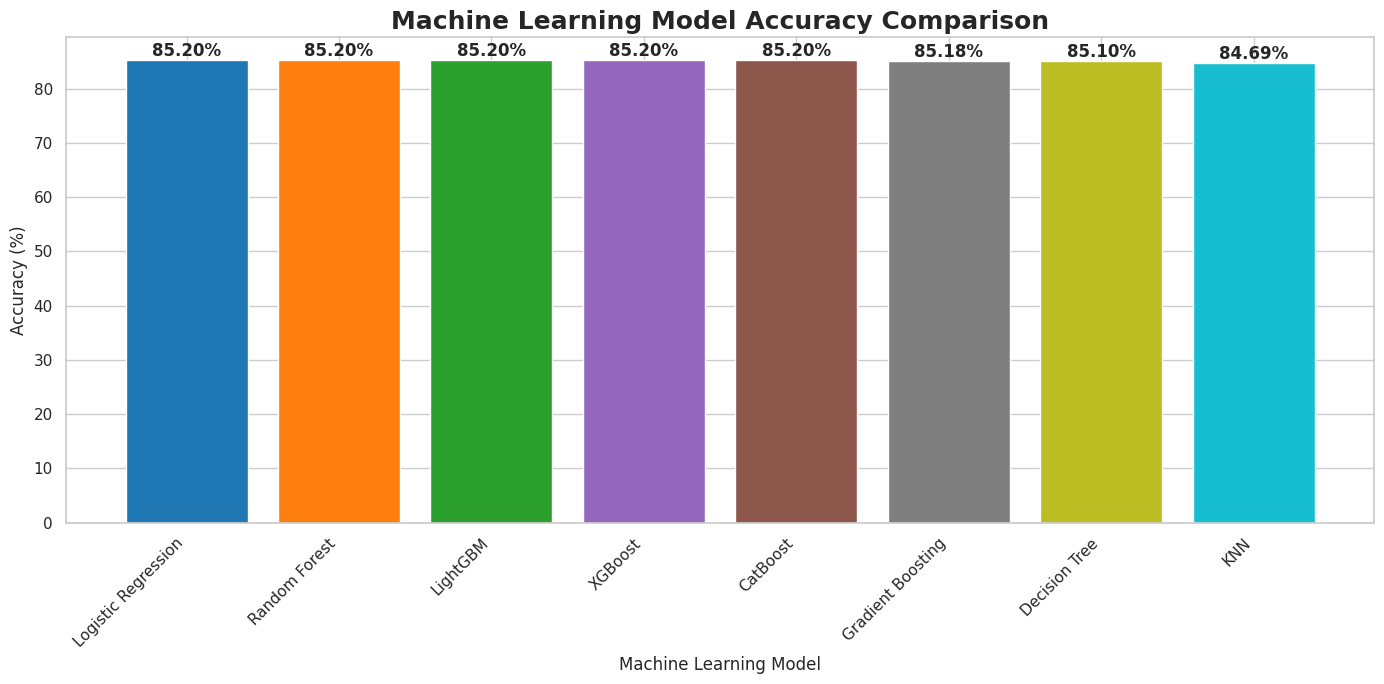

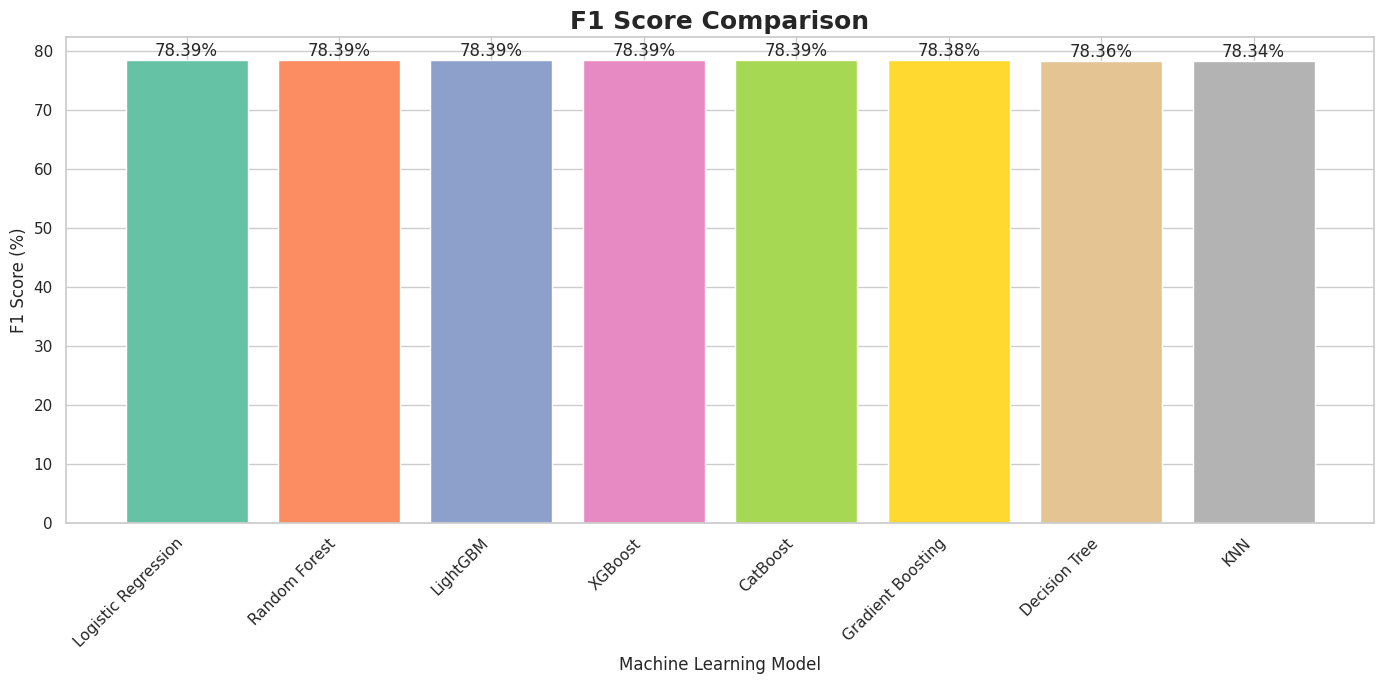

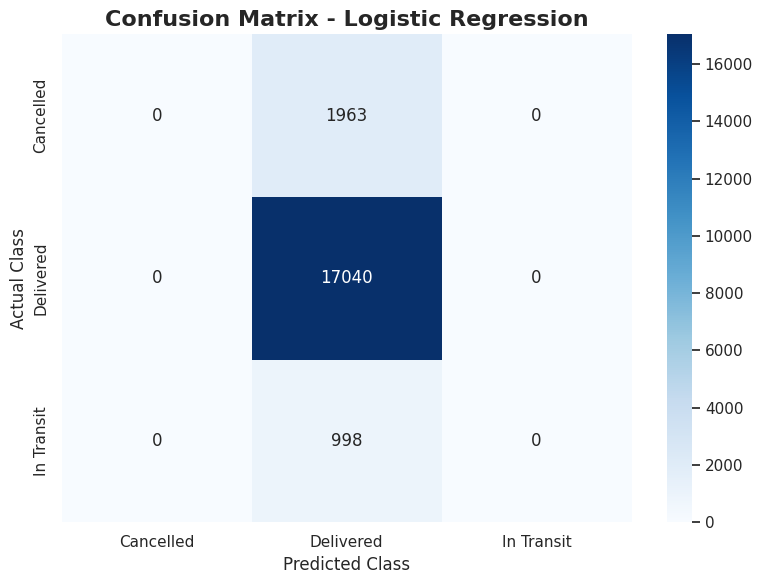

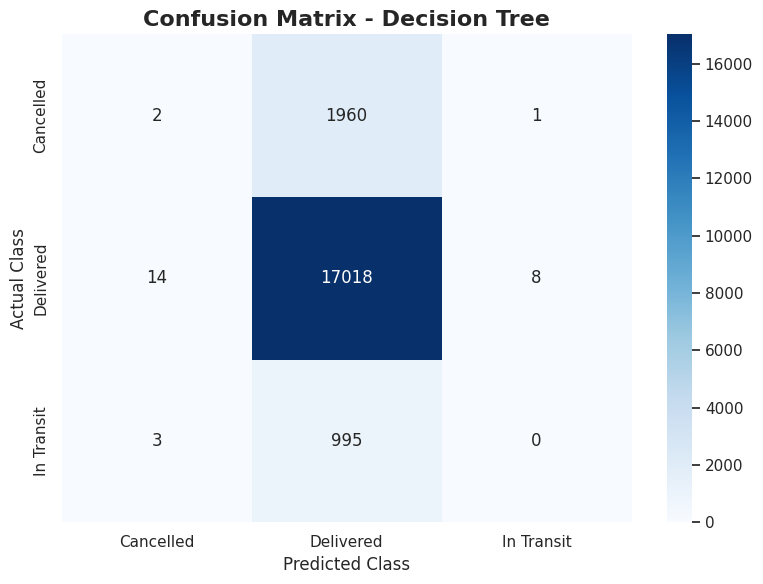

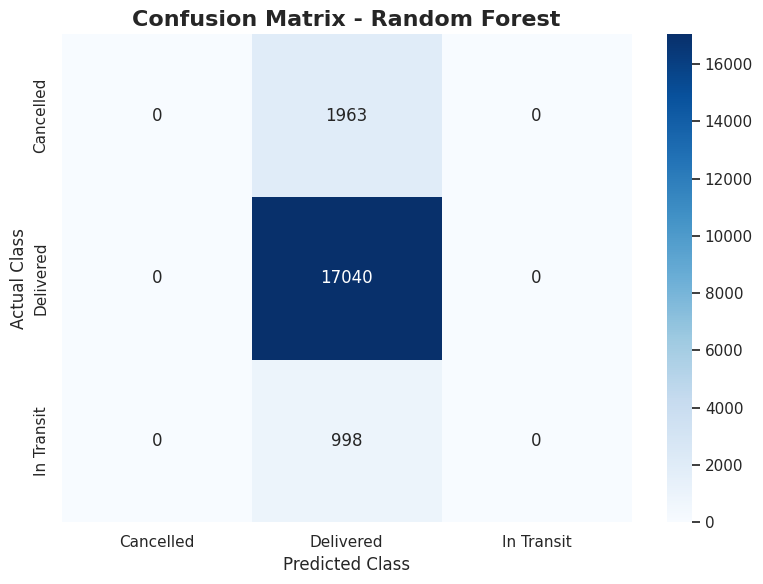

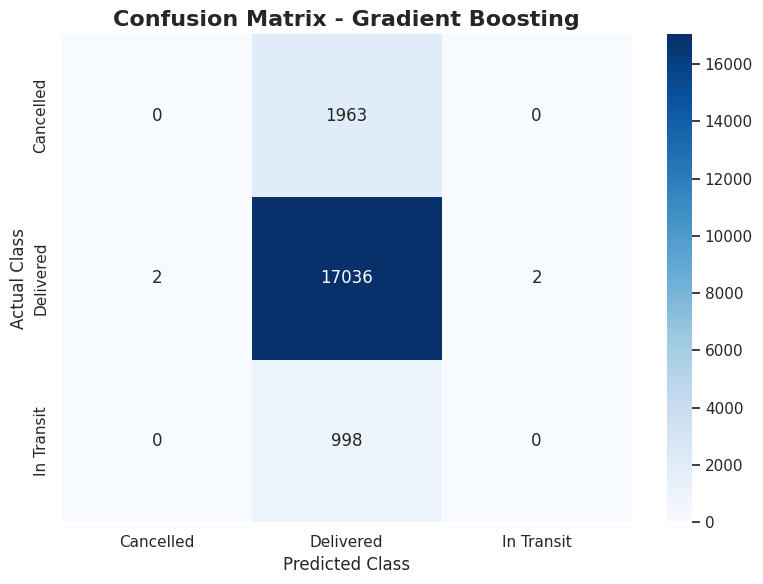

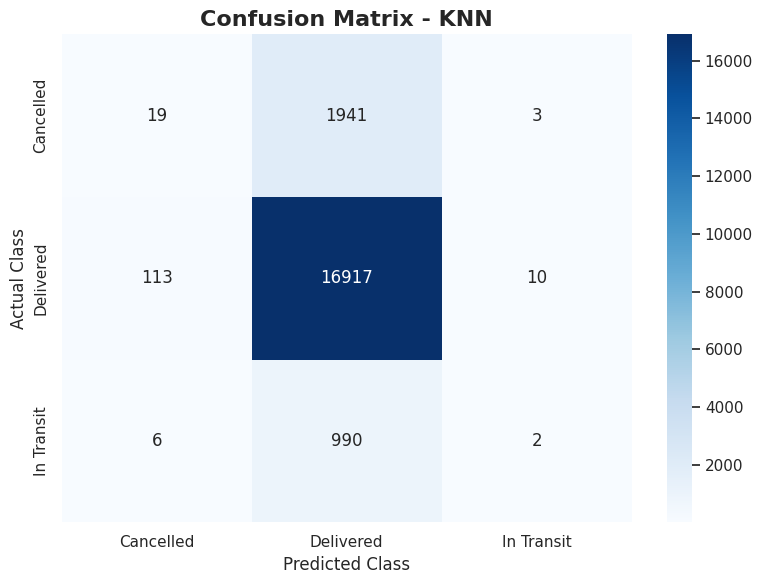

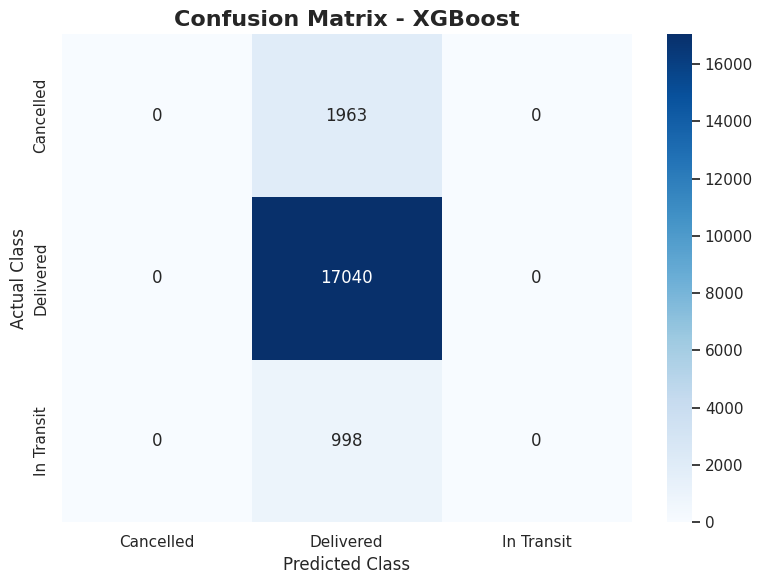

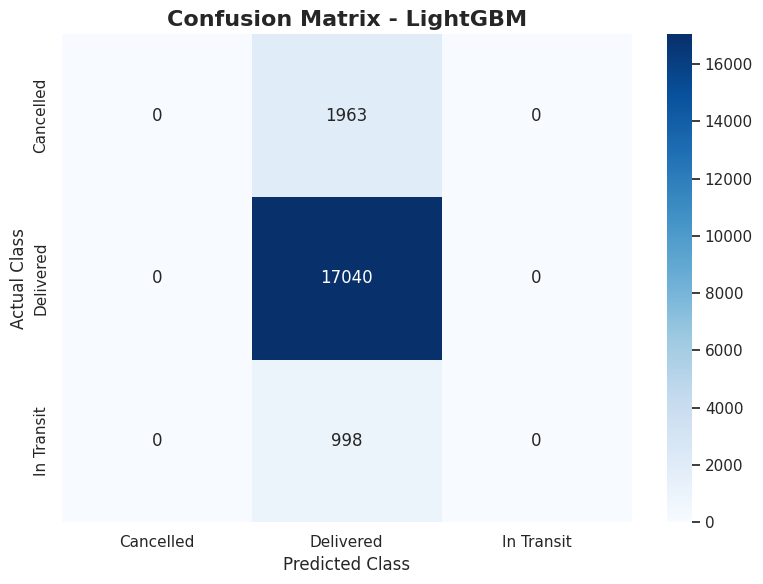

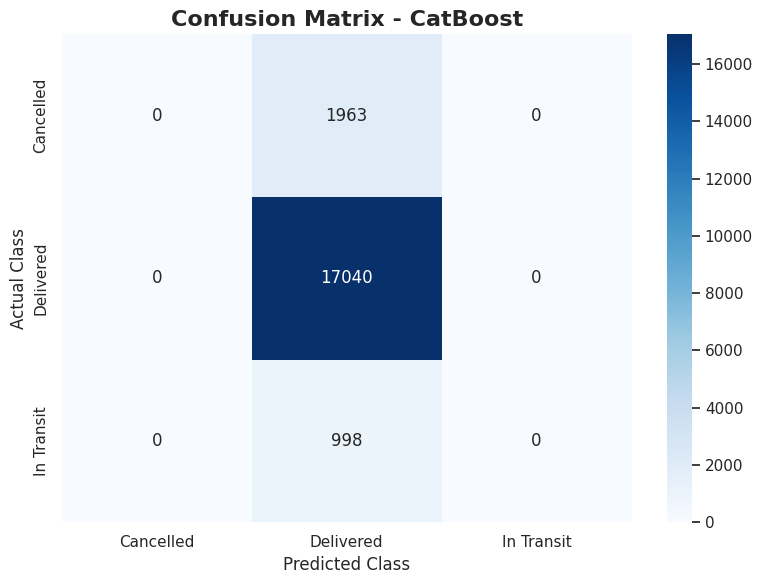



CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17040
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20001
   macro avg       0.28      0.33      0.31     20001
weighted avg       0.73      0.85      0.78     20001



CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

   Cancelled       0.11      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17040
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20001
   macro avg       0.32      0.33      0.31     20001
weighted avg       0.74      0.85      0.78     20001



CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   

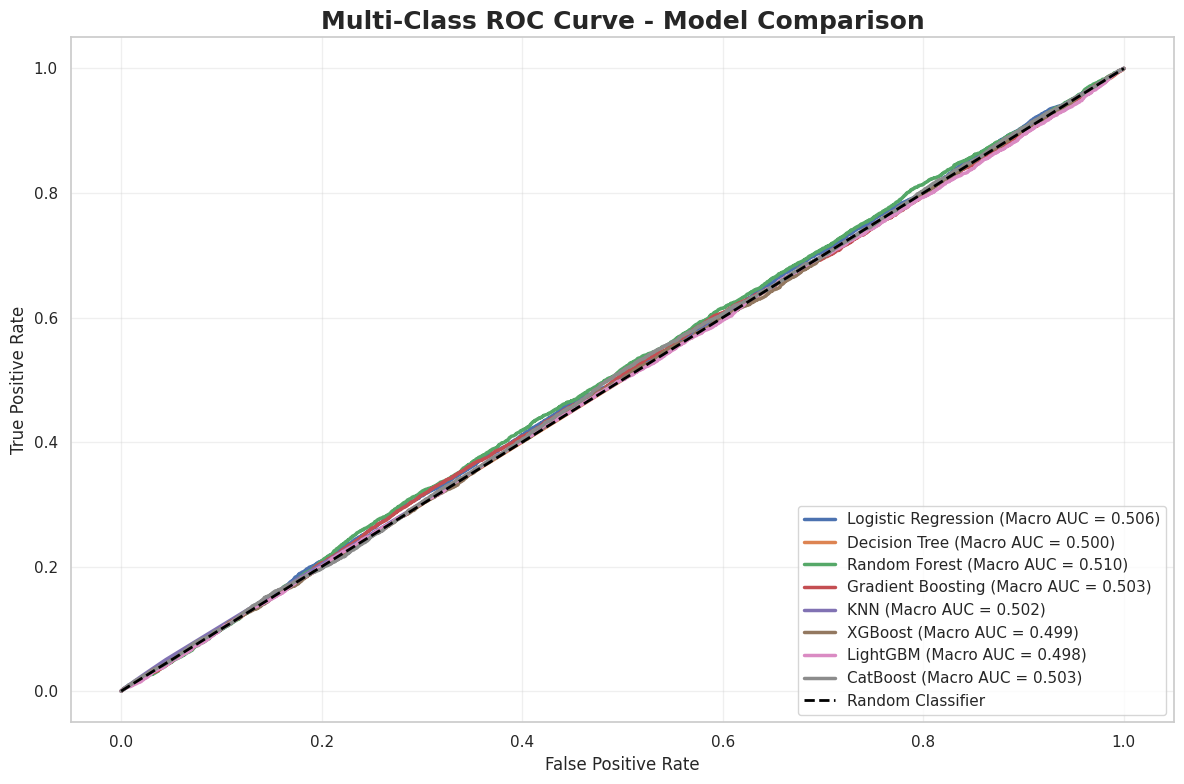

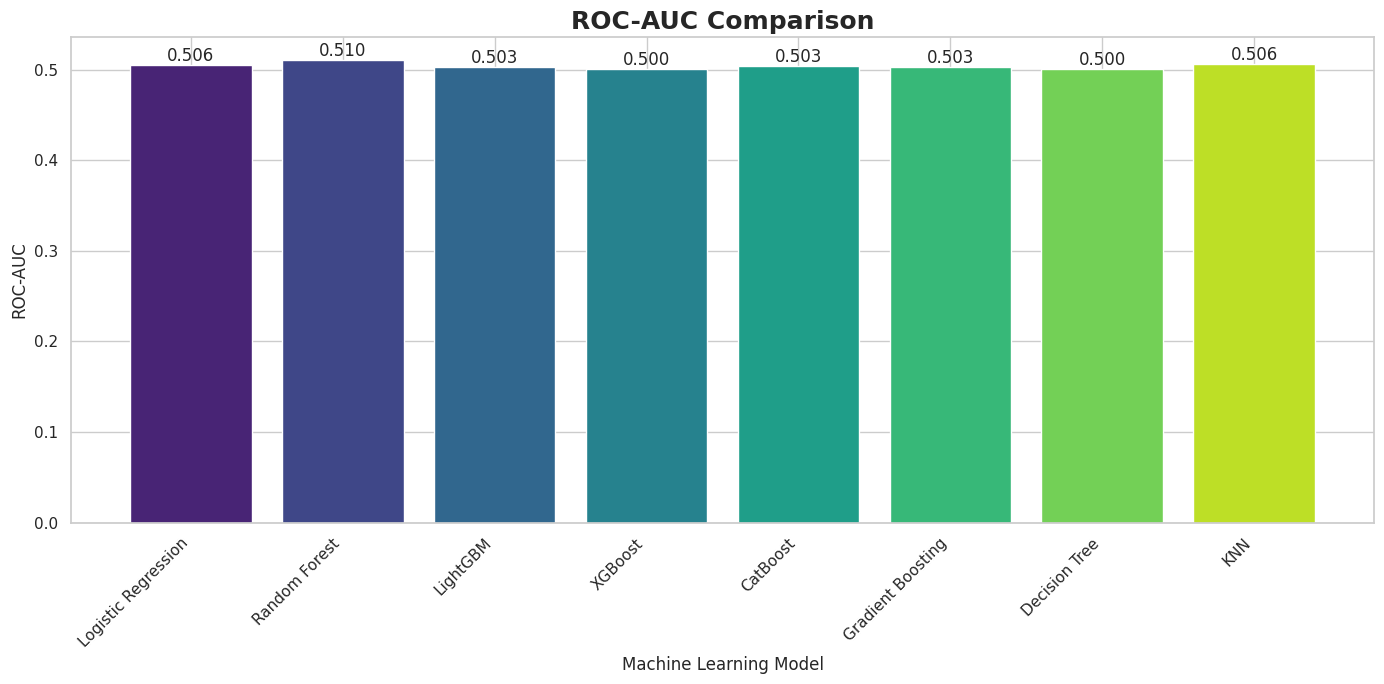



FINAL ML SUMMARY
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  ROC AUC
Logistic Regression     85.195740      72.583142   85.195740     78.385325 0.505535
      Random Forest     85.195740      72.583142   85.195740     78.385325 0.510048
           LightGBM     85.195740      72.583142   85.195740     78.385325 0.502506
            XGBoost     85.195740      72.583142   85.195740     78.385325 0.500211
           CatBoost     85.195740      72.583142   85.195740     78.385325 0.503404
  Gradient Boosting     85.175741      72.580619   85.175741     78.375388 0.502901
      Decision Tree     85.095745      73.624160   85.095745     78.363152 0.500320
                KNN     84.685766      74.631262   84.685766     78.339501 0.505693

Target Classes:
0 -> Cancelled
1 -> Delivered
2 -> In Transit

Machine Learning process completed successfully!


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. COPY DATASET
# ============================================================

data = df.copy()

print("=" * 80)
print("ORIGINAL DATASET")
print("=" * 80)

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())


# ============================================================
# 2. BASIC DATA CLEANING
# ============================================================

# Convert time columns
data["Order_Time"] = pd.to_datetime(
    data["Order_Time"],
    errors="coerce"
)

data["Delivery_Time"] = pd.to_datetime(
    data["Delivery_Time"],
    errors="coerce"
)


# ------------------------------------------------------------
# Convert numerical columns
# ------------------------------------------------------------

numeric_columns = [
    "Quantity",
    "Total_Price",
    "Delivery_Duration_Minutes",
    "Restaurant_Lat",
    "Restaurant_Lon",
    "Customer_Lat",
    "Customer_Lon",
    "Driver_Lat",
    "Driver_Lon",
    "Delivery_Distance_km"
]

for col in numeric_columns:

    if col in data.columns:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

# Extract useful information from Order_Time

data["Order_Hour"] = data["Order_Time"].dt.hour

data["Order_Day"] = data["Order_Time"].dt.day

data["Order_Month"] = data["Order_Time"].dt.month

data["Order_DayOfWeek"] = data["Order_Time"].dt.dayofweek


# ============================================================
# 4. DEFINE TARGET
# ============================================================

TARGET = "Order_Status"

print("\n" + "=" * 80)
print("TARGET VARIABLE")
print("=" * 80)

print("Target:", TARGET)

print("\nTarget Distribution:")
print(data[TARGET].value_counts())


# ============================================================
# 5. REMOVE ROWS WHERE TARGET IS MISSING
# ============================================================

data = data.dropna(
    subset=[TARGET]
).reset_index(drop=True)



drop_columns = [
    "Order_Status",
    "Order_ID",
    "User_ID",
    "Restaurant_ID",
    "Driver_ID",
    "Delivery_Time",
    "Delivery_Duration_Minutes",
    "Order_Time"
]

drop_columns = [
    col for col in drop_columns
    if col in data.columns
]


# ============================================================
# 7. CREATE X AND y
# ============================================================

X = data.drop(
    columns=drop_columns
)

y = data[TARGET].copy()


print("\n" + "=" * 80)
print("FEATURES")
print("=" * 80)

print(X.columns.tolist())

print("\nNumber of Features:", X.shape[1])


# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

# IMPORTANT:
# Train-test split is performed BEFORE encoding.
#
# This helps prevent information from the test set
# influencing preprocessing.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 9. LABEL ENCODING TARGET
# ============================================================

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

print("\n" + "=" * 80)
print("LABEL ENCODING")
print("=" * 80)

print("Original Classes:")
print(label_encoder.classes_)

print("\nEncoded Classes:")

for index, class_name in enumerate(label_encoder.classes_):

    print(
        class_name,
        "->",
        index
    )


# ============================================================
# 10. IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================================

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "int32", "float64", "float32", "bool"]
).columns.tolist()


print("\n" + "=" * 80)
print("CATEGORICAL FEATURES")
print("=" * 80)

print(categorical_features)


print("\n" + "=" * 80)
print("NUMERICAL FEATURES")
print("=" * 80)

print(numerical_features)


# ============================================================
# 11. NUMERICAL PIPELINE
# ============================================================

numerical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]
)


# ============================================================
# 12. CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]
)


# ============================================================
# 13. COLUMN TRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            numerical_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )

    ]
)


# ============================================================
# 14. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        )
}


# ============================================================
# 15. OPTIONAL XGBOOST
# ============================================================

try:

    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    )

    print("\nXGBoost available.")

except ImportError:

    print(
        "\nXGBoost is not installed."
        "\nSkipping XGBoost."
    )


# ============================================================
# 16. OPTIONAL LIGHTGBM
# ============================================================

try:

    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )

    print("LightGBM available.")

except ImportError:

    print(
        "LightGBM is not installed."
        "\nSkipping LightGBM."
    )


# ============================================================
# 17. OPTIONAL CATBOOST
# ============================================================

try:

    from catboost import CatBoostClassifier

    models["CatBoost"] = CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_seed=42
    )

    print("CatBoost available.")

except ImportError:

    print(
        "CatBoost is not installed."
        "\nSkipping CatBoost."
    )


# ============================================================
# 18. MODEL TRAINING
# ============================================================

results = []

trained_models = {}

predictions = {}

probabilities = {}


print("\n")
print("=" * 80)
print("MODEL TRAINING STARTED")
print("=" * 80)


for model_name, model in models.items():

    print("\n" + "-" * 80)

    print(
        "Training:",
        model_name
    )

    # --------------------------------------------------------
    # Create complete pipeline
    # --------------------------------------------------------

    pipeline = Pipeline(
        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                model
            )

        ]
    )


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train_encoded
    )


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = pipeline.predict(
        X_test
    )


    # --------------------------------------------------------
    # Probability predictions
    # --------------------------------------------------------

    y_probability = pipeline.predict_proba(
        X_test
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test_encoded,
        y_pred
    )

    precision = precision_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )


    # --------------------------------------------------------
    # ROC AUC
    # --------------------------------------------------------

    try:

        roc_auc = roc_auc_score(
            y_test_encoded,
            y_probability,
            multi_class="ovr",
            average="weighted"
        )

    except ValueError:

        roc_auc = np.nan


    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results.append({

        "Model": model_name,

        "Accuracy (%)":
            accuracy * 100,

        "Precision (%)":
            precision * 100,

        "Recall (%)":
            recall * 100,

        "F1 Score (%)":
            f1 * 100,

        "ROC AUC":
            roc_auc

    })


    trained_models[
        model_name
    ] = pipeline

    predictions[
        model_name
    ] = y_pred

    probabilities[
        model_name
    ] = y_probability


    # --------------------------------------------------------
    # Print metrics
    # --------------------------------------------------------

    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {f1 * 100:.2f}%"
    )

    print(
        f"ROC AUC   : {roc_auc:.4f}"
    )


# ============================================================
# 19. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(
    drop=True
)


print("\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 20. ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(
    figsize=(14, 7)
)

colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(results_df)
    )
)

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"],
    color=colors
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,

        height,

        f"{height:.2f}%",

        ha="center",

        va="bottom",

        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 21. F1 SCORE COMPARISON
# ============================================================

plt.figure(
    figsize=(14, 7)
)

f1_colors = plt.cm.Set2(
    np.linspace(
        0,
        1,
        len(results_df)
    )
)

bars = plt.bar(
    results_df["Model"],
    results_df["F1 Score (%)"],
    color=f1_colors
)

plt.title(
    "F1 Score Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "F1 Score (%)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,

        height,

        f"{height:.2f}%",

        ha="center",

        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 22. CONFUSION MATRICES
# ============================================================

for model_name in trained_models:

    y_pred = predictions[
        model_name
    ]

    cm = confusion_matrix(
        y_test_encoded,
        y_pred
    )


    plt.figure(
        figsize=(8, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "Actual Class"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. CLASSIFICATION REPORTS
# ============================================================

for model_name in trained_models:

    print("\n")
    print("=" * 80)

    print(
        f"CLASSIFICATION REPORT - {model_name}"
    )

    print("=" * 80)


    print(
        classification_report(
            y_test_encoded,
            predictions[model_name],
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


# ============================================================
# 24. ROC CURVES
# ============================================================

print("\n")
print("=" * 80)
print("ROC CURVE ANALYSIS")
print("=" * 80)

n_classes = len(
    label_encoder.classes_
)


# ------------------------------------------------------------
# CASE 1: BINARY CLASSIFICATION
# ------------------------------------------------------------

if n_classes == 2:

    plt.figure(
        figsize=(12, 8)
    )

    for model_name in trained_models:

        probability = probabilities[
            model_name
        ][:, 1]


        fpr, tpr, thresholds = roc_curve(
            y_test_encoded,
            probability
        )


        auc_value = roc_auc_score(
            y_test_encoded,
            probability
        )


        plt.plot(
            fpr,
            tpr,
            linewidth=2.5,
            label=f"{model_name} (AUC = {auc_value:.3f})"
        )


    # Random classifier line

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        linewidth=2,
        label="Random Classifier"
    )


    plt.title(
        "ROC Curve - Model Comparison",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# CASE 2: MULTI-CLASS CLASSIFICATION
# ------------------------------------------------------------

else:

    # Convert target into one-hot representation

    y_test_binary = label_binarize(
        y_test_encoded,
        classes=np.arange(n_classes)
    )


    plt.figure(
        figsize=(12, 8)
    )


    # --------------------------------------------------------
    # Calculate macro-average ROC for every model
    # --------------------------------------------------------

    for model_name in trained_models:

        probability = probabilities[
            model_name
        ]


        # Store FPR/TPR for each class

        fpr = {}
        tpr = {}


        for class_index in range(
            n_classes
        ):

            fpr[class_index], tpr[class_index], _ = roc_curve(
                y_test_binary[:, class_index],
                probability[:, class_index]
            )


        # ----------------------------------------------------
        # Collect all FPR points
        # ----------------------------------------------------

        all_fpr = np.unique(
            np.concatenate(
                [
                    fpr[i]
                    for i in range(n_classes)
                ]
            )
        )


        # ----------------------------------------------------
        # Interpolate TPR
        # ----------------------------------------------------

        mean_tpr = np.zeros_like(
            all_fpr
        )


        for class_index in range(
            n_classes
        ):

            mean_tpr += np.interp(
                all_fpr,
                fpr[class_index],
                tpr[class_index]
            )


        mean_tpr /= n_classes


        # ----------------------------------------------------
        # Calculate Macro AUC
        # ----------------------------------------------------

        macro_auc = roc_auc_score(
            y_test_binary,
            probability,
            multi_class="ovr",
            average="macro"
        )


        # ----------------------------------------------------
        # Plot model ROC
        # ----------------------------------------------------

        plt.plot(
            all_fpr,
            mean_tpr,
            linewidth=2.5,
            label=f"{model_name} (Macro AUC = {macro_auc:.3f})"
        )


    # Random classifier

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        linewidth=2,
        label="Random Classifier"
    )


    plt.title(
        "Multi-Class ROC Curve - Model Comparison",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. ROC-AUC COMPARISON
# ============================================================

plt.figure(
    figsize=(14, 7)
)

auc_colors = plt.cm.viridis(
    np.linspace(
        0.1,
        0.9,
        len(results_df)
    )
)

bars = plt.bar(
    results_df["Model"],
    results_df["ROC AUC"],
    color=auc_colors
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "ROC-AUC"
)

plt.xticks(
    rotation=45,
    ha="right"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,

        height,

        f"{height:.3f}",

        ha="center",

        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 26. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL ML SUMMARY")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)


print("\nTarget Classes:")

for i, class_name in enumerate(
    label_encoder.classes_
):

    print(
        f"{i} -> {class_name}"
    )


print("\nMachine Learning process completed successfully!")

## Thank you..pls upvote!!!!